# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
import os, glob, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, mean_squared_error, make_scorer

from scipy.stats import randint, uniform

# LightGBM
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not installed. Install with: pip install lightgbm")




## Model Selection

Baseline models included logistic regression and random forest, and a LightGBM classifier was additionally evaluated as a boosting-based model.


In [2]:
# =========================================================
# Load metadata
# =========================================================
# Load the metadata CSV file from URL
!wget -O hmp2_metadata.csv "https://g-227ca.190ebd.75bc.data.globus.org/ibdmdb/metadata/hmp2_metadata_2018-08-20.csv"

# Replace 'hmp2_metadata.csv' with the path to actual dataset
hmp_meta = pd.read_csv('hmp2_metadata.csv')

# ===========================================
# Save MGX sample id into a text file
# ===========================================
sample_ids = [
"MSMAPC57_taxonomic_profile_3.tsv",
"CSM79HN6_taxonomic_profile_3.tsv",
"CSM5MCXD_taxonomic_profile_3.tsv",
"PSM6XBT1_taxonomic_profile_3.tsv",
"PSM7J15Q_taxonomic_profile_3.tsv",
"HSM7J4Q7_taxonomic_profile_3.tsv",
"HSM7J4J7_taxonomic_profile_3.tsv",
"PSM6XBTB_taxonomic_profile_3.tsv",
"HSM6XRQ8_taxonomic_profile_3.tsv",
"HSM7J4P2_taxonomic_profile_3.tsv",
"MSMAPC6M_taxonomic_profile_3.tsv",
"HSM7J4QZ_taxonomic_profile_3.tsv",
"PSM6XBTN_P_taxonomic_profile_3.tsv",
"MSM79H7W_taxonomic_profile_3.tsv",
"MSM6J2RK_taxonomic_profile_3.tsv",
"MSMA267V_taxonomic_profile_3.tsv",
"CSM7KOKF_taxonomic_profile_3.tsv",
"CSM9X1Z4_taxonomic_profile_3.tsv",
"MSM6J2PQ_P_taxonomic_profile_3.tsv",
"HSM5MD7J_taxonomic_profile_3.tsv",
"CSM79HOV_taxonomic_profile_3.tsv",
"HSM6XRR9_taxonomic_profile_3.tsv",
"MSM5LLD6_P_taxonomic_profile_3.tsv",
"PSM6XBVS_taxonomic_profile_3.tsv",
"MSMA26AZ_TR_taxonomic_profile_3.tsv",
"CSM67UF1_taxonomic_profile_3.tsv",
"HSMA33IO_taxonomic_profile_3.tsv",
"CSMAAEUA_taxonomic_profile_3.tsv",
"HSMA33LZ_taxonomic_profile_3.tsv",
"HSMA33LH_TR_taxonomic_profile_3.tsv",
"CSM79HLE_taxonomic_profile_3.tsv",
"CSMA88CB_taxonomic_profile_3.tsv",
"CSM7KOTU_taxonomic_profile_3.tsv",
"HSM7CYXS_taxonomic_profile_3.tsv",
"MSM79H9W_taxonomic_profile_3.tsv",
"CSM67U9H_P_taxonomic_profile_3.tsv",
"CSM67UE3_taxonomic_profile_3.tsv",
"HSM5FZBP_P_taxonomic_profile_3.tsv",
"MSMB4LZ4_taxonomic_profile_3.tsv",
"PSMA265N_taxonomic_profile_3.tsv",
"MSM9VZLL_taxonomic_profile_3.tsv",
"HSM67VGE_P_taxonomic_profile_3.tsv",
"PSM7J1BF_taxonomic_profile_3.tsv",
"HSMA33ME_taxonomic_profile_3.tsv",
"HSM7J4L5_taxonomic_profile_3.tsv",
"CSM67UDN_taxonomic_profile_3.tsv",
"PSM7J1C2_P_taxonomic_profile_3.tsv",
"MSM6J2RS_taxonomic_profile_3.tsv",
"CSM67U9T_P_taxonomic_profile_3.tsv",
"HSMA33LB_taxonomic_profile_3.tsv",
"HSMA33R5_taxonomic_profile_3.tsv",
"PSM7J1CS_P_taxonomic_profile_3.tsv",
"CSM5FZ3Z_P_taxonomic_profile_3.tsv",
"PSM7J18G_taxonomic_profile_3.tsv",
"MSM6J2LL_taxonomic_profile_3.tsv",
"MSM9VZIQ_taxonomic_profile_3.tsv",
"CSM9X21L_taxonomic_profile_3.tsv",
"CSM7KON8_taxonomic_profile_3.tsv",
"HSM7J4PM_taxonomic_profile_3.tsv",
"PSM7J1A2_taxonomic_profile_3.tsv",
"CSM9X237_taxonomic_profile_3.tsv",
"CSM67U9D_taxonomic_profile_3.tsv",
"PSM7J14X_taxonomic_profile_3.tsv",
"MSM6J2RM_taxonomic_profile_3.tsv",
"CSM79HJC_P_taxonomic_profile_3.tsv",
"MSMA26AR_taxonomic_profile_3.tsv",
"CSM79HRC_taxonomic_profile_3.tsv",
"HSM5MD6M_taxonomic_profile_3.tsv",
"HSMA33RD_taxonomic_profile_3.tsv",
"HSMA33PZ_taxonomic_profile_3.tsv",
"HSM67VEM_TR_taxonomic_profile_3.tsv",
"MSM79H5A_taxonomic_profile_3.tsv",
"HSM7J4OP_taxonomic_profile_3.tsv",
"MSM6J2RA_taxonomic_profile_3.tsv",
"HSM7J4GP_taxonomic_profile_3.tsv",
"CSM67UAM_taxonomic_profile_3.tsv",
"MSMA267X_taxonomic_profile_3.tsv",
"MSM9VZGS_taxonomic_profile_3.tsv",
"MSM5LLGN_P_taxonomic_profile_3.tsv",
"HSM7J4N4_taxonomic_profile_3.tsv",
"PSMA269S_taxonomic_profile_3.tsv",
"MSM9VZHZ_taxonomic_profile_3.tsv",
"CSM7KOS7_taxonomic_profile_3.tsv",
"CSM67U9V_P_taxonomic_profile_3.tsv",
"MSM9VZLV_taxonomic_profile_3.tsv",
"CSM9X21N_taxonomic_profile_3.tsv",
"MSM9VZOU_taxonomic_profile_3.tsv",
"HSM7CYX6_taxonomic_profile_3.tsv",
"CSM67UBN_taxonomic_profile_3.tsv",
"HSM5MD71_taxonomic_profile_3.tsv",
"HSM67VDT_taxonomic_profile_3.tsv",
"HSM6XRTQ_taxonomic_profile_3.tsv",
"MSM9VZOK_taxonomic_profile_3.tsv",
"CSM7KOOF_taxonomic_profile_3.tsv",
"HSM6XRUN_taxonomic_profile_3.tsv",
"PSM7J15O_taxonomic_profile_3.tsv",
"HSM7J4M8_taxonomic_profile_3.tsv",
"MSM6J2JH_P_taxonomic_profile_3.tsv",
"MSM9VZN4_P_taxonomic_profile_3.tsv",
"MSM79H6B_taxonomic_profile_3.tsv",
"PSM7J1CC_taxonomic_profile_3.tsv",
"MSM6J2OH_taxonomic_profile_3.tsv",
"ESM5GEYY_P_taxonomic_profile_3.tsv",
"HSM6XRVU_taxonomic_profile_3.tsv",
"MSM79H8B_taxonomic_profile_3.tsv",
"MSM79HDS_taxonomic_profile_3.tsv",
"CSM79HPO_taxonomic_profile_3.tsv",
"MSM9VZJJ_P_taxonomic_profile_3.tsv",
"CSM7KOSL_taxonomic_profile_3.tsv",
"MSM79HCR_taxonomic_profile_3.tsv",
"HSMA33SK_taxonomic_profile_3.tsv",
"HSM7J4PG_taxonomic_profile_3.tsv",
"PSM7J19Z_taxonomic_profile_3.tsv",
"HSM7CZ1T_P_taxonomic_profile_3.tsv",
"HSM7CZ2J_P_taxonomic_profile_3.tsv",
"HSM7J4HO_taxonomic_profile_3.tsv",
"PSM6XBV2_taxonomic_profile_3.tsv",
"CSM7KONK_taxonomic_profile_3.tsv",
"HSM5MD87_P_taxonomic_profile_3.tsv",
"CSM7KOLY_taxonomic_profile_3.tsv",
"CSM7KONU_taxonomic_profile_3.tsv",
"HSM5MEE5_P_taxonomic_profile_3.tsv",
"HSM7CZ3G_taxonomic_profile_3.tsv",
"MSM6J2Q3_taxonomic_profile_3.tsv",
"HSM67VGA_taxonomic_profile_3.tsv",
"CSM7KOKP_P_taxonomic_profile_3.tsv",
"HSM67VDT_P_taxonomic_profile_3.tsv",
"CSM5FZ3X_P_taxonomic_profile_3.tsv",
"HSM5MD75_taxonomic_profile_3.tsv",
"MSM79H9G_taxonomic_profile_3.tsv",
"MSMA26BD_taxonomic_profile_3.tsv",
"PSMA263W_taxonomic_profile_3.tsv",
"HSM7CZ3E_taxonomic_profile_3.tsv",
"MSM79H67_taxonomic_profile_3.tsv",
"CSM67UAI_P_taxonomic_profile_3.tsv",
"CSM5MCV1_P_taxonomic_profile_3.tsv",
"HSM7CZ22_taxonomic_profile_3.tsv",
"MSM5LLFO_P_taxonomic_profile_3.tsv",
"MSMB4LZV_taxonomic_profile_3.tsv",
"CSM7KOOR_taxonomic_profile_3.tsv",
"MSM79H6F_taxonomic_profile_3.tsv",
"HSM67VH1_taxonomic_profile_3.tsv",
"CSM79HQF_taxonomic_profile_3.tsv",
"MSM6J2JT_taxonomic_profile_3.tsv",
"PSMB4MC1_taxonomic_profile_3.tsv",
"HSMA33J9_taxonomic_profile_3.tsv",
"HSMA33OP_taxonomic_profile_3.tsv",
"HSM7J4LD_taxonomic_profile_3.tsv",
"PSM7J1BB_taxonomic_profile_3.tsv",
"PSM7J16W_taxonomic_profile_3.tsv",
"HSM7CYY9_taxonomic_profile_3.tsv",
"MSM6J2RQ_taxonomic_profile_3.tsv",
"CSM9X1YV_taxonomic_profile_3.tsv",
"PSM7J184_taxonomic_profile_3.tsv",
"ESM5MEB7_taxonomic_profile_3.tsv",
"HSM6XRVK_taxonomic_profile_3.tsv",
"MSM5LLIK_P_taxonomic_profile_3.tsv",
"HSM67VDR_P_taxonomic_profile_3.tsv",
"CSM67UB9_taxonomic_profile_3.tsv",
"HSM7J4KK_taxonomic_profile_3.tsv",
"HSM7J4NS_taxonomic_profile_3.tsv",
"MSM6J2IG_taxonomic_profile_3.tsv",
"PSM7J1B7_taxonomic_profile_3.tsv",
"CSM79HNM_taxonomic_profile_3.tsv",
"PSM7J12Z_taxonomic_profile_3.tsv",
"CSM7KOPE_taxonomic_profile_3.tsv",
"CSM79HGJ_P_taxonomic_profile_3.tsv",
"MSMA26EJ_taxonomic_profile_3.tsv",
"CSMAG78W_taxonomic_profile_3.tsv",
"MSM6J2LW_taxonomic_profile_3.tsv",
"HSM67VG6_P_taxonomic_profile_3.tsv",
"CSM79HLM_taxonomic_profile_3.tsv",
"MSM6J2R8_taxonomic_profile_3.tsv",
"HSM5MD4N_taxonomic_profile_3.tsv",
"PSM6XBQS_taxonomic_profile_3.tsv",
"HSM7J4HW_taxonomic_profile_3.tsv",
"CSM7KOQP_P_taxonomic_profile_3.tsv",
"HSM7J4KC_taxonomic_profile_3.tsv",
"MSM9VZOI_taxonomic_profile_3.tsv",
"CSM67UBX_taxonomic_profile_3.tsv",
"PSMA265L_taxonomic_profile_3.tsv",
"CSM7KOKZ_taxonomic_profile_3.tsv",
"MSM6J2LT_taxonomic_profile_3.tsv",
"MSMA26AX_taxonomic_profile_3.tsv",
"HSM5MD5P_taxonomic_profile_3.tsv",
"HSM7J4PE_taxonomic_profile_3.tsv",
"MSM79H94_P_taxonomic_profile_3.tsv",
"HSM5MD8L_P_taxonomic_profile_3.tsv",
"MSM9VZHP_taxonomic_profile_3.tsv",
"CSM7KOSP_taxonomic_profile_3.tsv",
"CSM79HJ8_P_taxonomic_profile_3.tsv",
"MSMB4LYH_taxonomic_profile_3.tsv",
"MSM5LLGL_taxonomic_profile_3.tsv",
"MSM79HFB_taxonomic_profile_3.tsv",
"HSM7CYXC_taxonomic_profile_3.tsv",
"MSM79H63_taxonomic_profile_3.tsv",
"CSM5MCWC_taxonomic_profile_3.tsv",
"CSM79HKB_taxonomic_profile_3.tsv",
"CSM5MCUS_P_taxonomic_profile_3.tsv",
"MSM5LLH8_P_taxonomic_profile_3.tsv",
"MSMA26BV_taxonomic_profile_3.tsv",
"HSM7J4OE_taxonomic_profile_3.tsv",
"MSM5LLDK_taxonomic_profile_3.tsv",
"HSMA33MK_taxonomic_profile_3.tsv",
"CSM5MCXP_taxonomic_profile_3.tsv",
"CSM79HJ2_P_taxonomic_profile_3.tsv",
"HSM6XRQS_taxonomic_profile_3.tsv",
"HSM7J4PW_taxonomic_profile_3.tsv",
"HSM5MD6C_taxonomic_profile_3.tsv",
"PSM7J193_taxonomic_profile_3.tsv",
"HSM67VIL_taxonomic_profile_3.tsv",
"MSM9VZGO_taxonomic_profile_3.tsv",
"HSMA33J1_P_taxonomic_profile_3.tsv",
"HSM7J4IR_taxonomic_profile_3.tsv",
"MSM79HFY_taxonomic_profile_3.tsv",
"CSM79HR4_taxonomic_profile_3.tsv",
"MSMA26BB_taxonomic_profile_3.tsv",
"ESM5MEEJ_P_taxonomic_profile_3.tsv",
"CSM5MCUO_taxonomic_profile_3.tsv",
"HSM5MD7Z_P_taxonomic_profile_3.tsv",
"PSMA265J_taxonomic_profile_3.tsv",
"HSM5MD53_taxonomic_profile_3.tsv",
"CSM67UBH_taxonomic_profile_3.tsv",
"HSM6XRTC_P_taxonomic_profile_3.tsv",
"MSM9VZHB_taxonomic_profile_3.tsv",
"CSM5MCXF_P_taxonomic_profile_3.tsv",
"ESM718SY_taxonomic_profile_3.tsv",
"HSM7CYZJ_taxonomic_profile_3.tsv",
"HSM67VFR_taxonomic_profile_3.tsv",
"HSM67VHS_taxonomic_profile_3.tsv",
"CSM79HQ9_taxonomic_profile_3.tsv",
"HSMA33S4_taxonomic_profile_3.tsv",
"MSM6J2HL_taxonomic_profile_3.tsv",
"HSM7J4O7_taxonomic_profile_3.tsv",
"MSM79H8D_taxonomic_profile_3.tsv",
"MSM79HAJ_taxonomic_profile_3.tsv",
"HSM7J4HK_taxonomic_profile_3.tsv",
"HSM7J4Q1_taxonomic_profile_3.tsv",
"CSM79HQV_taxonomic_profile_3.tsv",
"MSM7J16J_taxonomic_profile_3.tsv",
"MSM79H5Y_taxonomic_profile_3.tsv",
"PSM7J19F_taxonomic_profile_3.tsv",
"HSM7CZ2V_P_taxonomic_profile_3.tsv",
"MSM9VZIY_taxonomic_profile_3.tsv",
"CSM67U9J_taxonomic_profile_3.tsv",
"PSMA267F_taxonomic_profile_3.tsv",
"HSM67VDX_P_taxonomic_profile_3.tsv",
"CSM67U9N_taxonomic_profile_3.tsv",
"HSMA33R1_taxonomic_profile_3.tsv",
"CSM5FZ4A_P_taxonomic_profile_3.tsv",
"PSM7J19H_taxonomic_profile_3.tsv",
"HSM6XRTG_P_taxonomic_profile_3.tsv",
"MSM6J2IO_taxonomic_profile_3.tsv",
"CSM9X1ZY_taxonomic_profile_3.tsv",
"MSM79H9U_P_taxonomic_profile_3.tsv",
"MSM9VZMS_taxonomic_profile_3.tsv",
"MSM5LLGD_P_taxonomic_profile_3.tsv",
"CSM79HGN_P_taxonomic_profile_3.tsv",
"CSMA9J65_taxonomic_profile_3.tsv",
"MSM5LLF2_P_taxonomic_profile_3.tsv",
"ESM5ME9H_P_taxonomic_profile_3.tsv",
"HSM5FZC2_P_taxonomic_profile_3.tsv",
"CSM79HJW_taxonomic_profile_3.tsv",
"PSM6XBSC_P_taxonomic_profile_3.tsv",
"CSM79HNY_P_taxonomic_profile_3.tsv",
"CSM5MCVF_P_taxonomic_profile_3.tsv",
"CSM79HIT_taxonomic_profile_3.tsv",
"CSM67UAS_taxonomic_profile_3.tsv",
"HSM7J4L9_taxonomic_profile_3.tsv",
"ESM5MEE2_P_taxonomic_profile_3.tsv",
"MSM5LLFG_P_taxonomic_profile_3.tsv",
"HSM5MD6Q_taxonomic_profile_3.tsv",
"PSM6XBRK_taxonomic_profile_3.tsv",
"HSM6XRR7_taxonomic_profile_3.tsv",
"HSM7CZ1V_taxonomic_profile_3.tsv",
"MSM6J2IQ_taxonomic_profile_3.tsv",
"MSM5LLIG_P_taxonomic_profile_3.tsv",
"HSM5MD8J_P_taxonomic_profile_3.tsv",
"HSM5MD66_taxonomic_profile_3.tsv",
"CSM7KOSJ_taxonomic_profile_3.tsv",
"MSM9VZOW_taxonomic_profile_3.tsv",
"HSM7J4GD_taxonomic_profile_3.tsv",
"PSM7J1BX_taxonomic_profile_3.tsv",
"MSM9VZEM_taxonomic_profile_3.tsv",
"CSM7KOL2_taxonomic_profile_3.tsv",
"ESM5MEC7_P_taxonomic_profile_3.tsv",
"MSM9VZHJ_taxonomic_profile_3.tsv",
"MSM6J2JZ_taxonomic_profile_3.tsv",
"HSM6XRQY_taxonomic_profile_3.tsv",
"MSM9VZEK_taxonomic_profile_3.tsv",
"MSM6J2QD_taxonomic_profile_3.tsv",
"ESM5MEBI_taxonomic_profile_3.tsv",
"CSM79HGH_P_taxonomic_profile_3.tsv",
"HSM7J4MC_taxonomic_profile_3.tsv",
"PSMB4MC3_taxonomic_profile_3.tsv",
"PSM6XBTR_taxonomic_profile_3.tsv",
"PSM7J15S_taxonomic_profile_3.tsv",
"HSM6XRSX_P_taxonomic_profile_3.tsv",
"MSMA26BL_taxonomic_profile_3.tsv",
"PSM7J13Y_P_taxonomic_profile_3.tsv",
"PSM6XBS4_P_taxonomic_profile_3.tsv",
"PSMA266Y_taxonomic_profile_3.tsv",
"MSM6J2Q7_taxonomic_profile_3.tsv",
"CSM7KOUN_taxonomic_profile_3.tsv",
"PSM7J177_taxonomic_profile_3.tsv",
"PSM6XBU2_taxonomic_profile_3.tsv",
"HSMA33KO_taxonomic_profile_3.tsv",
"MSM6J2R2_taxonomic_profile_3.tsv",
"HSM6XRUV_taxonomic_profile_3.tsv",
"CSM79HI7_taxonomic_profile_3.tsv",
"HSM5MD6O_P_taxonomic_profile_3.tsv",
"MSM6J2HR_taxonomic_profile_3.tsv",
"HSM7CYZV_taxonomic_profile_3.tsv",
"PSM6XBUG_taxonomic_profile_3.tsv",
"MSM9VZEY_taxonomic_profile_3.tsv",
"HSM7CYXI_taxonomic_profile_3.tsv",
"PSM7J19R_taxonomic_profile_3.tsv",
"PSM7J12V_taxonomic_profile_3.tsv",
"HSM67VCX_P_taxonomic_profile_3.tsv",
"CSM79HIR_taxonomic_profile_3.tsv",
"HSMA33P2_P_taxonomic_profile_3.tsv",
"CSM79HRG_taxonomic_profile_3.tsv",
"PSMA2659_taxonomic_profile_3.tsv",
"MSM79H5Q_taxonomic_profile_3.tsv",
"MSM79H8J_P_taxonomic_profile_3.tsv",
"CSM7KOPO_taxonomic_profile_3.tsv",
"PSM7J17F_taxonomic_profile_3.tsv",
"HSMA33IC_taxonomic_profile_3.tsv",
"MSM9VZFJ_P_taxonomic_profile_3.tsv",
"MSM6J2JP_taxonomic_profile_3.tsv",
"HSMA33OD_taxonomic_profile_3.tsv",
"MSM9VZMI_taxonomic_profile_3.tsv",
"HSM6XRSX_taxonomic_profile_3.tsv",
"HSM7J4JZ_taxonomic_profile_3.tsv",
"HSMA33JR_taxonomic_profile_3.tsv",
"HSM7J4RE_taxonomic_profile_3.tsv",
"HSM7J4QT_taxonomic_profile_3.tsv",
"HSM7J4NU_taxonomic_profile_3.tsv",
"MSM9VZMU_taxonomic_profile_3.tsv",
"HSM7CYXQ_taxonomic_profile_3.tsv",
"HSM5MD6I_taxonomic_profile_3.tsv",
"MSM5FZ9X_P_taxonomic_profile_3.tsv",
"MSM79H6L_taxonomic_profile_3.tsv",
"PSM6XBR1_taxonomic_profile_3.tsv",
"HSMA33RX_taxonomic_profile_3.tsv",
"MSM5LLHX_P_taxonomic_profile_3.tsv",
"MSMA26EZ_taxonomic_profile_3.tsv",
"CSM5MCX3_taxonomic_profile_3.tsv",
"CSM67UAY_taxonomic_profile_3.tsv",
"HSM7J4MW_taxonomic_profile_3.tsv",
"MSM9VZHL_taxonomic_profile_3.tsv",
"CSM79HNU_taxonomic_profile_3.tsv",
"CSM79HOT_taxonomic_profile_3.tsv",
"MSM79HDQ_taxonomic_profile_3.tsv",
"MSMA2688_taxonomic_profile_3.tsv",
"MSM5LLDC_taxonomic_profile_3.tsv",
"PSM6XBSM_taxonomic_profile_3.tsv",
"PSM6XBS4_taxonomic_profile_3.tsv",
"MSMA26AP_taxonomic_profile_3.tsv",
"PSM7J1BV_taxonomic_profile_3.tsv",
"MSM79H98_taxonomic_profile_3.tsv",
"CSM7KOPK_taxonomic_profile_3.tsv",
"HSM7CZ1G_taxonomic_profile_3.tsv",
"MSM79H5E_taxonomic_profile_3.tsv",
"PSM6XBUK_taxonomic_profile_3.tsv",
"CSM7KOOV_taxonomic_profile_3.tsv",
"CSM79HIX_taxonomic_profile_3.tsv",
"MSM79H6N_taxonomic_profile_3.tsv",
"HSM6XRTG_taxonomic_profile_3.tsv",
"MSM6J2QH_taxonomic_profile_3.tsv",
"CSM79HK9_taxonomic_profile_3.tsv",
"HSMA33MS_taxonomic_profile_3.tsv",
"CSM7KOU7_P_taxonomic_profile_3.tsv",
"PSM7J1BL_taxonomic_profile_3.tsv",
"HSM67VID_taxonomic_profile_3.tsv",
"MSMAPC7T_taxonomic_profile_3.tsv",
"MSMA26ER_taxonomic_profile_3.tsv",
"CSM5MCWQ_taxonomic_profile_3.tsv",
"MSM9VZLX_P_taxonomic_profile_3.tsv",
"HSMA33PN_taxonomic_profile_3.tsv",
"PSM7J13I_taxonomic_profile_3.tsv",
"PSM7J173_taxonomic_profile_3.tsv",
"MSM6J2IK_taxonomic_profile_3.tsv",
"HSM6XRS4_taxonomic_profile_3.tsv",
"PSMA267R_taxonomic_profile_3.tsv",
"HSM7J4QD_taxonomic_profile_3.tsv",
"HSM67VI9_taxonomic_profile_3.tsv",
"HSM5MD6S_P_taxonomic_profile_3.tsv",
"MSMA26ET_taxonomic_profile_3.tsv",
"CSM79HPM_P_taxonomic_profile_3.tsv",
"CSM79HH4_taxonomic_profile_3.tsv",
"HSM67VG2_P_taxonomic_profile_3.tsv",
"ESM5MECQ_taxonomic_profile_3.tsv",
"HSM67VEK_taxonomic_profile_3.tsv",
"MSM79H8F_taxonomic_profile_3.tsv",
"MSM6J2IE_taxonomic_profile_3.tsv",
"ESM5MEBE_taxonomic_profile_3.tsv",
"HSM67VD6_taxonomic_profile_3.tsv",
"HSM5MD4U_P_taxonomic_profile_3.tsv",
"HSMA33J5_taxonomic_profile_3.tsv",
"CSM5MCXH_taxonomic_profile_3.tsv",
"ESM7F5CD_taxonomic_profile_3.tsv",
"CSM7KOUJ_P_taxonomic_profile_3.tsv",
"HSM67VFH_taxonomic_profile_3.tsv",
"MSM5LLF8_taxonomic_profile_3.tsv",
"CSM7KOTC_taxonomic_profile_3.tsv",
"HSM5MD3Y_taxonomic_profile_3.tsv",
"MSM5LLIQ_P_taxonomic_profile_3.tsv",
"CSM5MCVZ_P_taxonomic_profile_3.tsv",
"CSM5FZ42_P_taxonomic_profile_3.tsv",
"HSM67VEW_taxonomic_profile_3.tsv",
"CSM9X1ZC_taxonomic_profile_3.tsv",
"PSM7J19J_taxonomic_profile_3.tsv",
"MSM79H81_taxonomic_profile_3.tsv",
"CSM79HID_taxonomic_profile_3.tsv",
"CSM9X1ZQ_taxonomic_profile_3.tsv",
"HSM7J4HS_taxonomic_profile_3.tsv",
"HSM67VHK_taxonomic_profile_3.tsv",
"CSM79HJS_taxonomic_profile_3.tsv",
"HSM67VFJ_taxonomic_profile_3.tsv",
"HSM5MD57_P_taxonomic_profile_3.tsv",
"MSM5LLER_taxonomic_profile_3.tsv",
"MSM9VZMM_taxonomic_profile_3.tsv",
"CSM7KOMR_P_taxonomic_profile_3.tsv",
"PSM6XBTL_taxonomic_profile_3.tsv",
"HSMA33JP_taxonomic_profile_3.tsv",
"HSM5MD5B_P_taxonomic_profile_3.tsv",
"MSM79HDK_taxonomic_profile_3.tsv",
"HSM6XRQI_taxonomic_profile_3.tsv",
"CSM5MCUY_P_taxonomic_profile_3.tsv",
"MSMAPC6E_taxonomic_profile_3.tsv",
"CSM5MCUQ_P_taxonomic_profile_3.tsv",
"MSMA26EL_taxonomic_profile_3.tsv",
"CSM5MCZD_taxonomic_profile_3.tsv",
"CSM7KOR4_P_taxonomic_profile_3.tsv",
"CSM67UET_P_taxonomic_profile_3.tsv",
"CSM67UFZ_taxonomic_profile_3.tsv",
"MSM6J2MJ_taxonomic_profile_3.tsv",
"CSMACTZP_taxonomic_profile_3.tsv",
"MSM6J2K4_taxonomic_profile_3.tsv",
"MSMAPC5H_taxonomic_profile_3.tsv",
"CSM7KOJQ_taxonomic_profile_3.tsv",
"ESM5MEAB_P_taxonomic_profile_3.tsv",
"MSM6J2RG_P_taxonomic_profile_3.tsv",
"HSM7J4PK_taxonomic_profile_3.tsv",
"MSM6J2JN_taxonomic_profile_3.tsv",
"ESM718TK_taxonomic_profile_3.tsv",
"HSM67VI7_taxonomic_profile_3.tsv",
"HSM6XRT8_taxonomic_profile_3.tsv",
"CSM67UAO_taxonomic_profile_3.tsv",
"HSM7J4HY_taxonomic_profile_3.tsv",
"CSM7KOJY_taxonomic_profile_3.tsv",
"MSM9VZOO_taxonomic_profile_3.tsv",
"PSM6XBTD_taxonomic_profile_3.tsv",
"CSM67UB3_taxonomic_profile_3.tsv",
"PSM7J156_taxonomic_profile_3.tsv",
"HSM7J4PU_taxonomic_profile_3.tsv",
"CSM79HGF_taxonomic_profile_3.tsv",
"MSM79H52_P_taxonomic_profile_3.tsv",
"MSM79HDU_taxonomic_profile_3.tsv",
"HSM67VHJ_taxonomic_profile_3.tsv",
"MSM79HF7_taxonomic_profile_3.tsv",
"HSM6XRQB_taxonomic_profile_3.tsv",
"PSMA2651_P_taxonomic_profile_3.tsv",
"MSM79HEW_taxonomic_profile_3.tsv",
"HSM6XRQE_P_taxonomic_profile_3.tsv",
"HSM5MD6A_TR_taxonomic_profile_3.tsv",
"HSMA33L1_taxonomic_profile_3.tsv",
"CSM79HJQ_taxonomic_profile_3.tsv",
"PSM6XBUO_taxonomic_profile_3.tsv",
"PSMB4MBI_taxonomic_profile_3.tsv",
"HSM7J4IS_taxonomic_profile_3.tsv",
"MSM79HB6_taxonomic_profile_3.tsv",
"MSMA26DO_taxonomic_profile_3.tsv",
"HSM7J4PO_taxonomic_profile_3.tsv",
"MSM9VZHF_taxonomic_profile_3.tsv",
"HSMA33NQ_taxonomic_profile_3.tsv",
"CSM5MCVJ_P_taxonomic_profile_3.tsv",
"CSM7KOUB_taxonomic_profile_3.tsv",
"CSM67UB5_P_taxonomic_profile_3.tsv",
"PSM7J19X_P_taxonomic_profile_3.tsv",
"MSMA26DM_taxonomic_profile_3.tsv",
"MSM5LLEP_taxonomic_profile_3.tsv",
"CSM67U9X_P_taxonomic_profile_3.tsv",
"MSM6J2PM_taxonomic_profile_3.tsv",
"CSM67UDR_taxonomic_profile_3.tsv",
"MSM6J2QJ_taxonomic_profile_3.tsv",
"HSM7J4O1_taxonomic_profile_3.tsv",
"MSM9VZO2_taxonomic_profile_3.tsv",
"MSM6J2QB_taxonomic_profile_3.tsv",
"HSM67VIJ_P_taxonomic_profile_3.tsv",
"PSMA265D_taxonomic_profile_3.tsv",
"CSM5FZ4K_P_taxonomic_profile_3.tsv",
"MSM9VZHN_taxonomic_profile_3.tsv",
"MSM79HA7_taxonomic_profile_3.tsv",
"MSMA26DK_taxonomic_profile_3.tsv",
"HSMA33R9_taxonomic_profile_3.tsv",
"MSM5LLGR_P_taxonomic_profile_3.tsv",
"HSM7CYY7_taxonomic_profile_3.tsv",
"PSM7J17Z_taxonomic_profile_3.tsv",
"MSM9VZI6_taxonomic_profile_3.tsv",
"CSM7KOOL_taxonomic_profile_3.tsv",
"CSM79HP2_taxonomic_profile_3.tsv",
"CSM79HOZ_taxonomic_profile_3.tsv",
"CSM79HNW_taxonomic_profile_3.tsv",
"CSM5MCXN_taxonomic_profile_3.tsv",
"CSM67UA2_taxonomic_profile_3.tsv",
"MSM6J2HJ_taxonomic_profile_3.tsv",
"MSMB4LZZ_taxonomic_profile_3.tsv",
"MSM9VZHT_taxonomic_profile_3.tsv",
"CSM7CZ2F_P_taxonomic_profile_3.tsv",
"HSMA33MG_taxonomic_profile_3.tsv",
"CSM5MCXL_taxonomic_profile_3.tsv",
"MSM5LLDS_taxonomic_profile_3.tsv",
"CSM7KOQX_taxonomic_profile_3.tsv",
"PSM7J17T_taxonomic_profile_3.tsv",
"HSM7J4I7_taxonomic_profile_3.tsv",
"MSM9VZKE_taxonomic_profile_3.tsv",
"PSMA264O_taxonomic_profile_3.tsv",
"CSM67UCK_taxonomic_profile_3.tsv",
"HSM5MD8A_P_taxonomic_profile_3.tsv",
"CSM79HJM_taxonomic_profile_3.tsv",
"ESM7F5C7_taxonomic_profile_3.tsv",
"PSM7J17D_taxonomic_profile_3.tsv",
"HSM7J4KA_taxonomic_profile_3.tsv",
"MSMAPC5D_taxonomic_profile_3.tsv",
"CSMAE44D_taxonomic_profile_3.tsv",
"CSM79HLG_taxonomic_profile_3.tsv",
"HSM7J4K8_taxonomic_profile_3.tsv",
"MSM79H58_taxonomic_profile_3.tsv",
"HSM7J4HM_taxonomic_profile_3.tsv",
"CSM7KOL4_taxonomic_profile_3.tsv",
"CSM9X22S_taxonomic_profile_3.tsv",
"HSM7CYZB_taxonomic_profile_3.tsv",
"MSM6J2LV_taxonomic_profile_3.tsv",
"CSM7KOPI_taxonomic_profile_3.tsv",
"MSM6J2PO_taxonomic_profile_3.tsv",
"PSM7J1BP_taxonomic_profile_3.tsv",
"PSM6XBT3_taxonomic_profile_3.tsv",
"HSM67VD4_taxonomic_profile_3.tsv",
"HSM5MD5B_taxonomic_profile_3.tsv",
"HSM67VGK_TR_taxonomic_profile_3.tsv",
"CSM79HMP_taxonomic_profile_3.tsv",
"HSMA33QO_taxonomic_profile_3.tsv",
"HSM67VI3_taxonomic_profile_3.tsv",
"CSM67UF5_taxonomic_profile_3.tsv",
"HSM6XRRB_taxonomic_profile_3.tsv",
"CSM5LLGB_P_taxonomic_profile_3.tsv",
"HSM5MD7Q_taxonomic_profile_3.tsv",
"MSM5LLIC_P_taxonomic_profile_3.tsv",
"MSM5LLI6_P_taxonomic_profile_3.tsv",
"PSMA266O_taxonomic_profile_3.tsv",
"MSM6J2JB_taxonomic_profile_3.tsv",
"CSM7KOKD_taxonomic_profile_3.tsv",
"HSM5MD8B_P_taxonomic_profile_3.tsv",
"HSM7J4IU_taxonomic_profile_3.tsv",
"MSM5LLI8_P_taxonomic_profile_3.tsv",
"PSM7J18I_taxonomic_profile_3.tsv",
"HSMA33NG_P_taxonomic_profile_3.tsv",
"MSM9VZMA_TR_taxonomic_profile_3.tsv",
"CSM7KOKB_taxonomic_profile_3.tsv",
"CSM5MCYW_taxonomic_profile_3.tsv",
"HSM7CYYH_taxonomic_profile_3.tsv",
"MSM79HD6_P_taxonomic_profile_3.tsv",
"MSMAPC6A_taxonomic_profile_3.tsv",
"HSM7J4M4_taxonomic_profile_3.tsv",
"MSM9VZMA_taxonomic_profile_3.tsv",
"HSM67VGA_P_taxonomic_profile_3.tsv",
"MSM79HBZ_taxonomic_profile_3.tsv",
"MSMB4LZC_taxonomic_profile_3.tsv",
"HSMA33KE_taxonomic_profile_3.tsv",
"MSM6J2MH_taxonomic_profile_3.tsv",
"HSMA33JZ_taxonomic_profile_3.tsv",
"MSM9VZL5_taxonomic_profile_3.tsv",
"CSM5MCXZ_P_taxonomic_profile_3.tsv",
"HSM6XRVW_taxonomic_profile_3.tsv",
"CSM5MCUW_P_taxonomic_profile_3.tsv",
"HSM7CYY5_taxonomic_profile_3.tsv",
"HSM5MD5X_P_taxonomic_profile_3.tsv",
"HSM7CYYV_P_taxonomic_profile_3.tsv",
"HSMA33OL_taxonomic_profile_3.tsv",
"HSM5MD7U_taxonomic_profile_3.tsv",
"MSMAPC6K_taxonomic_profile_3.tsv",
"MSM5LLGJ_P_taxonomic_profile_3.tsv",
"CSM7KOTO_taxonomic_profile_3.tsv",
"HSMA33KM_taxonomic_profile_3.tsv",
"CSM67UAG_taxonomic_profile_3.tsv",
"ESM7F5C5_taxonomic_profile_3.tsv",
"HSM7J4QB_taxonomic_profile_3.tsv",
"CSM7KOK3_taxonomic_profile_3.tsv",
"MSM5LLF4_taxonomic_profile_3.tsv",
"PSM7J14N_taxonomic_profile_3.tsv",
"ESM5MED2_taxonomic_profile_3.tsv",
"CSM79HGX_taxonomic_profile_3.tsv",
"HSM7J4I9_taxonomic_profile_3.tsv",
"MSM6J2KC_taxonomic_profile_3.tsv",
"MSM9VZP3_taxonomic_profile_3.tsv",
"PSM7J129_taxonomic_profile_3.tsv",
"CSM79HN2_taxonomic_profile_3.tsv",
"CSM7KOOX_taxonomic_profile_3.tsv",
"HSM6XRUL_taxonomic_profile_3.tsv",
"CSM7KOMT_taxonomic_profile_3.tsv",
"MSM9VZPN_taxonomic_profile_3.tsv",
"HSM7CZ2A_taxonomic_profile_3.tsv",
"HSM67VIB_taxonomic_profile_3.tsv",
"PSM7J12D_taxonomic_profile_3.tsv",
"HSM5MD82_P_taxonomic_profile_3.tsv",
"HSMA33R7_taxonomic_profile_3.tsv",
"MSM79HA1_taxonomic_profile_3.tsv",
"CSM79HR2_taxonomic_profile_3.tsv",
"MSM9VZLH_taxonomic_profile_3.tsv",
"PSM7J1BJ_taxonomic_profile_3.tsv",
"MSMA26AN_taxonomic_profile_3.tsv",
"HSMA33KS_taxonomic_profile_3.tsv",
"MSM7J16L_taxonomic_profile_3.tsv",
"ESM5GEZ3_P_taxonomic_profile_3.tsv",
"HSM7J4KG_taxonomic_profile_3.tsv",
"HSM7J4MY_taxonomic_profile_3.tsv",
"PSM7J1CU_taxonomic_profile_3.tsv",
"PSM7J163_taxonomic_profile_3.tsv",
"HSM7CYXE_taxonomic_profile_3.tsv",
"PSM7J1AW_taxonomic_profile_3.tsv",
"MSM79HDC_taxonomic_profile_3.tsv",
"HSM6XRVC_taxonomic_profile_3.tsv",
"CSM79HH8_taxonomic_profile_3.tsv",
"CSM79HPA_TR_taxonomic_profile_3.tsv",
"MSMA26AT_taxonomic_profile_3.tsv",
"HSMA33IK_taxonomic_profile_3.tsv",
"CSM7KOOP_taxonomic_profile_3.tsv",
"PSMB4MC5_taxonomic_profile_3.tsv",
"CSM67UBB_taxonomic_profile_3.tsv",
"PSM6XBVM_taxonomic_profile_3.tsv",
"MSM6J2QL_taxonomic_profile_3.tsv",
"HSM7CZ32_taxonomic_profile_3.tsv",
"MSM5LLIE_P_taxonomic_profile_3.tsv",
"HSM7J4JN_taxonomic_profile_3.tsv",
"MSM79HBV_taxonomic_profile_3.tsv",
"MSM5LLDE_taxonomic_profile_3.tsv",
"HSM6XRV8_taxonomic_profile_3.tsv",
"HSM6XRTO_taxonomic_profile_3.tsv",
"CSM7KORK_taxonomic_profile_3.tsv",
"CSM9X21R_taxonomic_profile_3.tsv",
"PSM7J18K_taxonomic_profile_3.tsv",
"MSM9VZEK_TR_taxonomic_profile_3.tsv",
"CSM5MCYI_P_taxonomic_profile_3.tsv",
"PSM7J1C4_taxonomic_profile_3.tsv",
"HSM7CZ3C_taxonomic_profile_3.tsv",
"HSMA33N4_taxonomic_profile_3.tsv",
"PSM7J1BH_taxonomic_profile_3.tsv",
"MSM6J2SK_taxonomic_profile_3.tsv",
"HSM6XRS8_taxonomic_profile_3.tsv",
"HSM7J4MK_taxonomic_profile_3.tsv",
"CSM7KOLM_taxonomic_profile_3.tsv",
"HSM5MD47_P_taxonomic_profile_3.tsv",
"CSM79HOF_taxonomic_profile_3.tsv",
"PSM7J4EF_taxonomic_profile_3.tsv",
"MSM6J2K2_taxonomic_profile_3.tsv",
"CSM9X219_taxonomic_profile_3.tsv",
"HSM7J4ON_taxonomic_profile_3.tsv",
"PSM7J16F_taxonomic_profile_3.tsv",
"CSM79HMT_taxonomic_profile_3.tsv",
"CSM67UDJ_taxonomic_profile_3.tsv",
"CSM67UDR_TR_taxonomic_profile_3.tsv",
"CSM7KONW_P_taxonomic_profile_3.tsv",
"HSM7J4OX_taxonomic_profile_3.tsv",
"PSM7J15K_taxonomic_profile_3.tsv",
"HSM67VDZ_taxonomic_profile_3.tsv",
"HSM67VHD_taxonomic_profile_3.tsv",
"HSM7J4K2_taxonomic_profile_3.tsv",
"MSM79HBT_taxonomic_profile_3.tsv",
"CSM7KOKT_taxonomic_profile_3.tsv",
"CSM9X233_taxonomic_profile_3.tsv",
"HSM7J4R2_taxonomic_profile_3.tsv",
"ESM5GEYW_P_taxonomic_profile_3.tsv",
"CSM5MCTZ_P_taxonomic_profile_3.tsv",
"HSM6XRQO_taxonomic_profile_3.tsv",
"CSM67UEP_P_taxonomic_profile_3.tsv",
"HSMA33MZ_taxonomic_profile_3.tsv",
"HSM7J4JV_P_taxonomic_profile_3.tsv",
"CSM79HMN_taxonomic_profile_3.tsv",
"MSM5LLHA_P_taxonomic_profile_3.tsv",
"HSM7J4QH_taxonomic_profile_3.tsv",
"CSM79HIB_taxonomic_profile_3.tsv",
"HSM7J4N6_taxonomic_profile_3.tsv",
"HSM6XRUX_taxonomic_profile_3.tsv",
"CSM7KOJO_taxonomic_profile_3.tsv",
"MSM79H89_taxonomic_profile_3.tsv",
"MSM79H9K_taxonomic_profile_3.tsv",
"HSM7J4MS_taxonomic_profile_3.tsv",
"MSM9VZOQ_taxonomic_profile_3.tsv",
"HSM67VFF_taxonomic_profile_3.tsv",
"CSM67UAQ_taxonomic_profile_3.tsv",
"MSM5LLHO_P_taxonomic_profile_3.tsv",
"HSM6XRUZ_taxonomic_profile_3.tsv",
"CSM9X23N_taxonomic_profile_3.tsv",
"CSM67UH7_taxonomic_profile_3.tsv",
"HSM5MD79_taxonomic_profile_3.tsv",
"HSM6XRRV_taxonomic_profile_3.tsv",
"HSM6XRQM_taxonomic_profile_3.tsv",
"CSM7KOQ5_P_taxonomic_profile_3.tsv",
"CSM7KOK1_taxonomic_profile_3.tsv",
"PSM6XBSO_taxonomic_profile_3.tsv",
"CSM79HG5_taxonomic_profile_3.tsv",
"MSM6J2Q9_taxonomic_profile_3.tsv",
"PSMA269W_taxonomic_profile_3.tsv",
"HSM7J4IW_taxonomic_profile_3.tsv",
"HSM7CZ36_taxonomic_profile_3.tsv",
"HSM5FZBR_P_taxonomic_profile_3.tsv",
"PSM7J12F_taxonomic_profile_3.tsv",
"PSMA266Q_taxonomic_profile_3.tsv",
"MSM6J2ML_taxonomic_profile_3.tsv",
"ESM5MEBS_taxonomic_profile_3.tsv",
"HSM7J4OB_taxonomic_profile_3.tsv",
"HSM7J4PI_taxonomic_profile_3.tsv",
"HSM7CZ2E_taxonomic_profile_3.tsv",
"HSM7CZ3A_taxonomic_profile_3.tsv",
"CSM5MCWM_P_taxonomic_profile_3.tsv",
"HSMA33JN_taxonomic_profile_3.tsv",
"CSM7KORC_taxonomic_profile_3.tsv",
"CSM79HJA_taxonomic_profile_3.tsv",
"HSM67VHH_taxonomic_profile_3.tsv",
"PSMA265F_taxonomic_profile_3.tsv",
"PSM7J179_taxonomic_profile_3.tsv",
"PSM6XBSI_taxonomic_profile_3.tsv",
"MSM6J2JF_P_taxonomic_profile_3.tsv",
"PSM7J1AO_taxonomic_profile_3.tsv",
"CSM7KOMX_taxonomic_profile_3.tsv",
"MSM6J2N6_P_taxonomic_profile_3.tsv",
"HSM67VI1_taxonomic_profile_3.tsv",
"HSM6XRT2_P_taxonomic_profile_3.tsv",
"MSMA26CV_taxonomic_profile_3.tsv",
"HSM5MD5Z_P_taxonomic_profile_3.tsv",
"CSM5FZ44_P_taxonomic_profile_3.tsv",
"ESM718V4_taxonomic_profile_3.tsv",
"HSMA33MC_taxonomic_profile_3.tsv",
"HSM7CYXG_taxonomic_profile_3.tsv",
"CSM7KOOH_taxonomic_profile_3.tsv",
"HSM7J4N8_taxonomic_profile_3.tsv",
"MSM79H8L_taxonomic_profile_3.tsv",
"MSM9VZLR_taxonomic_profile_3.tsv",
"CSM5MCWI_P_taxonomic_profile_3.tsv",
"HSMA33PL_taxonomic_profile_3.tsv",
"MSMAPC7P_taxonomic_profile_3.tsv",
"PSM7J13E_taxonomic_profile_3.tsv",
"PSMA267J_taxonomic_profile_3.tsv",
"MSM79HD8_P_taxonomic_profile_3.tsv",
"HSM7CZ2Z_taxonomic_profile_3.tsv",
"MSM9VZIS_taxonomic_profile_3.tsv",
"HSM7J4JF_taxonomic_profile_3.tsv",
"HSM67VES_taxonomic_profile_3.tsv",
"HSM5MD4P_P_taxonomic_profile_3.tsv",
"MSM9VZKI_taxonomic_profile_3.tsv",
"HSM5MD4W_P_taxonomic_profile_3.tsv",
"CSM67UAA_taxonomic_profile_3.tsv",
"MSM5LLFU_P_taxonomic_profile_3.tsv",
"MSMAPC6O_taxonomic_profile_3.tsv",
"CSM67UBZ_taxonomic_profile_3.tsv",
"HSM6XRT4_P_taxonomic_profile_3.tsv",
"CSM67UBF_taxonomic_profile_3.tsv",
"HSM6XRTE_P_taxonomic_profile_3.tsv",
"HSM6XRSI_taxonomic_profile_3.tsv",
"MSMAPC6C_taxonomic_profile_3.tsv",
"MSM9VZPT_taxonomic_profile_3.tsv",
"CSM79HLA_TR_taxonomic_profile_3.tsv",
"PSM7J13U_P_taxonomic_profile_3.tsv",
"CSM5MCYQ_P_taxonomic_profile_3.tsv",
"MSM9VZIM_taxonomic_profile_3.tsv",
"MSM9VZLB_taxonomic_profile_3.tsv",
"CSM67U9P_P_taxonomic_profile_3.tsv",
"CSM7KORO_taxonomic_profile_3.tsv",
"PSM7J13Q_taxonomic_profile_3.tsv",
"HSM5MD6K_taxonomic_profile_3.tsv",
"MSM9VZEO_taxonomic_profile_3.tsv",
"MSM79H9M_taxonomic_profile_3.tsv",
"CSM7KOUL_taxonomic_profile_3.tsv",
"MSMA26BR_taxonomic_profile_3.tsv",
"HSM7J4IQ_taxonomic_profile_3.tsv",
"CSM5YRY7_P_taxonomic_profile_3.tsv",
"HSM7J4Q9_taxonomic_profile_3.tsv",
"MSM79HDM_taxonomic_profile_3.tsv",
"HSMA33OJ_taxonomic_profile_3.tsv",
"PSMA26A1_taxonomic_profile_3.tsv",
"CSM5MCY4_taxonomic_profile_3.tsv",
"MSM6J2IY_taxonomic_profile_3.tsv",
"MSM79HBP_taxonomic_profile_3.tsv",
"CSM7KOKL_P_taxonomic_profile_3.tsv",
"ESM5MEDN_taxonomic_profile_3.tsv",
"MSM6J2HB_taxonomic_profile_3.tsv",
"PSM6XBTT_taxonomic_profile_3.tsv",
"HSM7J4IC_taxonomic_profile_3.tsv",
"CSM79HJO_taxonomic_profile_3.tsv",
"MSM7J16R_taxonomic_profile_3.tsv",
"PSM7J1AQ_taxonomic_profile_3.tsv",
"PSM7J14R_taxonomic_profile_3.tsv",
"MSM79H7E_taxonomic_profile_3.tsv",
"HSM7CZ1E_taxonomic_profile_3.tsv",
"HSM7CYWS_P_taxonomic_profile_3.tsv",
"MSM79HCP_taxonomic_profile_3.tsv",
"CSM7KON2_taxonomic_profile_3.tsv",
"PSM7J1AM_taxonomic_profile_3.tsv",
"MSM6J2OJ_taxonomic_profile_3.tsv",
"MSM9VZOY_taxonomic_profile_3.tsv",
"MSM79HEY_taxonomic_profile_3.tsv",
"MSM5LLGH_P_taxonomic_profile_3.tsv",
"HSM7CZ2H_taxonomic_profile_3.tsv",
"PSM6XBW3_taxonomic_profile_3.tsv",
"CSMA8M9R_taxonomic_profile_3.tsv",
"MSMB4LZK_taxonomic_profile_3.tsv",
"CSM67UAW_taxonomic_profile_3.tsv",
"HSM5MD7S_taxonomic_profile_3.tsv",
"MSMAPC5Z_taxonomic_profile_3.tsv",
"HSM67VGK_taxonomic_profile_3.tsv",
"HSMA33NO_taxonomic_profile_3.tsv",
"HSMA33SI_taxonomic_profile_3.tsv",
"HSM7J4OZ_taxonomic_profile_3.tsv",
"PSM6XBSU_taxonomic_profile_3.tsv",
"PSM7J16H_taxonomic_profile_3.tsv",
"MSM9VZHR_taxonomic_profile_3.tsv",
"CSM7KOJU_taxonomic_profile_3.tsv",
"CSM5MCVN_taxonomic_profile_3.tsv",
"HSM7J4O5_taxonomic_profile_3.tsv",
"MSM6J2HT_taxonomic_profile_3.tsv",
"CSM5MCVL_taxonomic_profile_3.tsv",
"HSM5MD4B_P_taxonomic_profile_3.tsv",
"MSMAPC7J_taxonomic_profile_3.tsv",
"HSMA33LJ_taxonomic_profile_3.tsv",
"CSM5FZ46_P_taxonomic_profile_3.tsv",
"MSM79H9Q_taxonomic_profile_3.tsv",
"PSM7J12B_taxonomic_profile_3.tsv",
"CSM9X222_taxonomic_profile_3.tsv",
"MSM79H5U_taxonomic_profile_3.tsv",
"PSMA264U_taxonomic_profile_3.tsv",
"HSM5MD7O_taxonomic_profile_3.tsv",
"CSM79HR6_taxonomic_profile_3.tsv",
"HSM7J4PS_taxonomic_profile_3.tsv",
"PSM7J14P_taxonomic_profile_3.tsv",
"HSM5MD5D_P_taxonomic_profile_3.tsv",
"HSM6XRV2_taxonomic_profile_3.tsv",
"CSM67UFV_taxonomic_profile_3.tsv",
"MSM79HF9_TR_taxonomic_profile_3.tsv",
"PSM7J15W_taxonomic_profile_3.tsv",
"MSM6J2PU_taxonomic_profile_3.tsv",
"PSM6XBVI_taxonomic_profile_3.tsv",
"MSM6J2LJ_taxonomic_profile_3.tsv",
"CSM5MCYM_P_taxonomic_profile_3.tsv",
"PSMA265T_taxonomic_profile_3.tsv",
"PSM7J1A4_taxonomic_profile_3.tsv",
"ESM5MEC3_taxonomic_profile_3.tsv",
"HSMA33LX_taxonomic_profile_3.tsv",
"ESM5GEYX_P_taxonomic_profile_3.tsv",
"HSM7CZ1A_taxonomic_profile_3.tsv",
"MSM6J2OP_taxonomic_profile_3.tsv",
"CSM7KOR2_taxonomic_profile_3.tsv",
"HSM7CYZF_taxonomic_profile_3.tsv",
"CSM79HM7_taxonomic_profile_3.tsv",
"CSM9X211_taxonomic_profile_3.tsv",
"HSM6XRSZ_P_taxonomic_profile_3.tsv",
"MSMB4LZR_taxonomic_profile_3.tsv",
"PSM7J1A6_taxonomic_profile_3.tsv",
"HSM7CYZR_taxonomic_profile_3.tsv",
"HSMA33RX_TR_taxonomic_profile_3.tsv",
"HSM6XRQK_taxonomic_profile_3.tsv",
"HSM6XRSG_taxonomic_profile_3.tsv",
"MSM9VZJZ_taxonomic_profile_3.tsv",
"PSMA269G_taxonomic_profile_3.tsv",
"CSM7KOSX_taxonomic_profile_3.tsv",
"PSM7J1AU_taxonomic_profile_3.tsv",
"HSM6XRV4_taxonomic_profile_3.tsv",
"MSM9VZH7_taxonomic_profile_3.tsv",
"PSM6XBTF_P_taxonomic_profile_3.tsv",
"HSM5MD59_P_taxonomic_profile_3.tsv",
"PSM7J16U_taxonomic_profile_3.tsv",
"HSM5MD8P_P_taxonomic_profile_3.tsv",
"CSM67UAK_taxonomic_profile_3.tsv",
"MSMA26DI_taxonomic_profile_3.tsv",
"MSM9VZFF_taxonomic_profile_3.tsv",
"PSM7J199_taxonomic_profile_3.tsv",
"HSM7CZ1C_taxonomic_profile_3.tsv",
"HSM5FZBZ_taxonomic_profile_3.tsv",
"HSM67VGI_P_taxonomic_profile_3.tsv",
"MSM6J2PK_taxonomic_profile_3.tsv",
"HSM67VGC_taxonomic_profile_3.tsv",
"ESM9IEP1_taxonomic_profile_3.tsv",
"CSM7KOU9_taxonomic_profile_3.tsv",
"CSM79HOL_taxonomic_profile_3.tsv",
"CSM5MCU8_P_taxonomic_profile_3.tsv",
"CSM5MCXT_taxonomic_profile_3.tsv",
"MSMA26EN_taxonomic_profile_3.tsv",
"MSM9VZNH_taxonomic_profile_3.tsv",
"CSM79HHA_taxonomic_profile_3.tsv",
"CSM5MCXR_taxonomic_profile_3.tsv",
"PSM7J1DF_taxonomic_profile_3.tsv",
"ESM5MEDU_taxonomic_profile_3.tsv",
"PSM6XBTZ_P_taxonomic_profile_3.tsv",
"PSM7J186_taxonomic_profile_3.tsv",
"CSM79HL6_taxonomic_profile_3.tsv",
"MSM6J2MF_taxonomic_profile_3.tsv",
"CSM79HM9_P_taxonomic_profile_3.tsv",
"HSM7J4J9_taxonomic_profile_3.tsv",
"HSM67VEQ_taxonomic_profile_3.tsv",
"MSM6J2Q1_taxonomic_profile_3.tsv",
"HSM7J4LF_taxonomic_profile_3.tsv",
"CSM79HJ6_P_taxonomic_profile_3.tsv",
"MSM6J2M3_taxonomic_profile_3.tsv",
"PSM6XBS8_taxonomic_profile_3.tsv",
"MSM5ZOJY_P_taxonomic_profile_3.tsv",
"MSM6J2LB_taxonomic_profile_3.tsv",
"MSM9VZL9_taxonomic_profile_3.tsv",
"MSM79HDG_TR_taxonomic_profile_3.tsv",
"MSM6J2JR_taxonomic_profile_3.tsv",
"PSM6XBUI_taxonomic_profile_3.tsv",
"PSM7J161_taxonomic_profile_3.tsv",
"ESM5MEC9_taxonomic_profile_3.tsv",
"CSM79HP6_taxonomic_profile_3.tsv",
"HSM5MD8N_P_taxonomic_profile_3.tsv",
"HSM6XRQC_P_taxonomic_profile_3.tsv",
"HSM7J4O3_taxonomic_profile_3.tsv",
"CSM7KOOJ_taxonomic_profile_3.tsv",
"MSM9VZIO_taxonomic_profile_3.tsv",
"PSM7J18M_taxonomic_profile_3.tsv",
"PSM7J1C8_taxonomic_profile_3.tsv",
"CSM9X213_taxonomic_profile_3.tsv",
"HSM7CZ28_taxonomic_profile_3.tsv",
"HSM7J4JT_P_taxonomic_profile_3.tsv",
"CSM9X22U_taxonomic_profile_3.tsv",
"HSM7J4KI_taxonomic_profile_3.tsv",
"ESM5MECL_taxonomic_profile_3.tsv",
"MSM9VZI2_taxonomic_profile_3.tsv",
"MSMAPC64_taxonomic_profile_3.tsv",
"CSM67UB1_taxonomic_profile_3.tsv",
"CSM5FZ3T_P_taxonomic_profile_3.tsv",
"MSM9VZGU_taxonomic_profile_3.tsv",
"HSMA33IG_taxonomic_profile_3.tsv",
"PSMA263S_taxonomic_profile_3.tsv",
"CSM7KOK7_taxonomic_profile_3.tsv",
"MSM9VZF3_taxonomic_profile_3.tsv",
"CSM5MCXV_taxonomic_profile_3.tsv",
"CSM79HQT_P_taxonomic_profile_3.tsv",
"CSM79HGD_P_taxonomic_profile_3.tsv",
"CSM7KORM_taxonomic_profile_3.tsv",
"MSM9VZLN_taxonomic_profile_3.tsv",
"MSM79HAN_taxonomic_profile_3.tsv",
"MSM79H6Y_taxonomic_profile_3.tsv",
"PSM6XBTX_taxonomic_profile_3.tsv",
"CSM79HPQ_P_taxonomic_profile_3.tsv",
"CSM5MCY2_taxonomic_profile_3.tsv",
"MSM9VZLD_taxonomic_profile_3.tsv",
"PSM6XBVO_taxonomic_profile_3.tsv",
"HSM7CYYP_taxonomic_profile_3.tsv",
"PSM6XBUQ_taxonomic_profile_3.tsv",
"PSM6XBSE_P_taxonomic_profile_3.tsv",
"MSM6J2RO_taxonomic_profile_3.tsv",
"MSM79HCN_P_taxonomic_profile_3.tsv",
"MSM6J2LY_taxonomic_profile_3.tsv",
"HSM5MD6W_taxonomic_profile_3.tsv",
"HSM6XRQW_taxonomic_profile_3.tsv",
"MSM79HBN_taxonomic_profile_3.tsv",
"ESM5MEA7_P_taxonomic_profile_3.tsv",
"HSM7CYX8_taxonomic_profile_3.tsv",
"PSM7J1CI_taxonomic_profile_3.tsv",
"HSMA33J3_taxonomic_profile_3.tsv",
"HSM6XRUR_taxonomic_profile_3.tsv",
"PSMA264K_taxonomic_profile_3.tsv",
"CSM67U9B_taxonomic_profile_3.tsv",
"HSM6XRR5_taxonomic_profile_3.tsv",
"HSMA33RR_taxonomic_profile_3.tsv",
"MSM6J2QR_taxonomic_profile_3.tsv",
"PSM7J141_taxonomic_profile_3.tsv",
"PSM7J1BD_taxonomic_profile_3.tsv",
"PSM6XBUM_taxonomic_profile_3.tsv",
"CSM79HIN_taxonomic_profile_3.tsv",
"CSM79HPC_taxonomic_profile_3.tsv",
"CSM7KOOD_taxonomic_profile_3.tsv",
"PSM6XBSS_taxonomic_profile_3.tsv",
"MSMAPC5L_taxonomic_profile_3.tsv",
"CSM9X22K_taxonomic_profile_3.tsv",
"CSM7KOKN_taxonomic_profile_3.tsv",
"MSM6J2K6_taxonomic_profile_3.tsv",
"MSM79HF1_P_taxonomic_profile_3.tsv",
"MSMB4LXW_taxonomic_profile_3.tsv",
"HSM67VDP_taxonomic_profile_3.tsv",
"PSM7J13Y_taxonomic_profile_3.tsv",
"PSMA266C_taxonomic_profile_3.tsv",
"CSM79HG7_P_taxonomic_profile_3.tsv",
"CSM7KOMV_P_taxonomic_profile_3.tsv",
"HSM7CYZL_taxonomic_profile_3.tsv",
"CSM7KOPM_taxonomic_profile_3.tsv",
"MSM9VZMO_taxonomic_profile_3.tsv",
"PSM7J127_taxonomic_profile_3.tsv",
"MSM5LLHQ_P_taxonomic_profile_3.tsv",
"HSMA33MI_taxonomic_profile_3.tsv",
"PSMA267P_taxonomic_profile_3.tsv",
"CSM67UDY_taxonomic_profile_3.tsv",
"HSM7CYZ5_taxonomic_profile_3.tsv",
"CSM79HPK_taxonomic_profile_3.tsv",
"CSM67UC6_taxonomic_profile_3.tsv",
"MSM79H6H_taxonomic_profile_3.tsv",
"MSM9VZGW_taxonomic_profile_3.tsv",
"HSM7J4HU_taxonomic_profile_3.tsv",
"PSM6XBQY_TR_taxonomic_profile_3.tsv",
"CSM79HHU_taxonomic_profile_3.tsv",
"HSM5MD6K_P_taxonomic_profile_3.tsv",
"MSM9VZEU_taxonomic_profile_3.tsv",
"CSM5MCWG_taxonomic_profile_3.tsv",
"CSM5MCZ7_taxonomic_profile_3.tsv",
"CSM9X1Y5_taxonomic_profile_3.tsv",
"MSM79H7G_taxonomic_profile_3.tsv",
"HSMA33OZ_taxonomic_profile_3.tsv",
"HSM67VEU_taxonomic_profile_3.tsv",
"CSM79HGZ_taxonomic_profile_3.tsv",
"MSMAPC59_taxonomic_profile_3.tsv",
"MSM6J2MD_taxonomic_profile_3.tsv",
"PSM7J1B3_P_taxonomic_profile_3.tsv",
"HSM7CYYB_taxonomic_profile_3.tsv",
"CSM67UB7_P_taxonomic_profile_3.tsv",
"MSM79HDE_taxonomic_profile_3.tsv",
"MSM6J2JD_taxonomic_profile_3.tsv",
"MSM79HDQ_TR_taxonomic_profile_3.tsv",
"PSM7J14L_taxonomic_profile_3.tsv",
"PSM6XBT5_taxonomic_profile_3.tsv",
"MSM9VZNH_TR_taxonomic_profile_3.tsv",
"PSMA269O_taxonomic_profile_3.tsv",
"MSM79H87_taxonomic_profile_3.tsv",
"HSM5MD8D_P_taxonomic_profile_3.tsv",
"PSM7J12R_taxonomic_profile_3.tsv",
"CSMAHYLR_taxonomic_profile_3.tsv",
"PSM7J17L_taxonomic_profile_3.tsv",
"PSMA266I_taxonomic_profile_3.tsv",
"PSM7J169_taxonomic_profile_3.tsv",
"CSM5MCVD_P_taxonomic_profile_3.tsv",
"PSM6XBW1_P_taxonomic_profile_3.tsv",
"HSM67VF3_taxonomic_profile_3.tsv",
"HSM5MD7W_P_taxonomic_profile_3.tsv",
"ESM5GEZ1_P_taxonomic_profile_3.tsv",
"HSM6XRTM_taxonomic_profile_3.tsv",
"ESM5MEB9_P_taxonomic_profile_3.tsv",
"MSMAPC55_taxonomic_profile_3.tsv",
"HSM7CZ24_taxonomic_profile_3.tsv",
"HSM7J4HC_taxonomic_profile_3.tsv",
"MSM79H7Y_taxonomic_profile_3.tsv",
"MSM79H7O_taxonomic_profile_3.tsv",
"CSM5MCWE_taxonomic_profile_3.tsv",
"MSM9VZLZ_taxonomic_profile_3.tsv",
"MSMA26EH_taxonomic_profile_3.tsv",
"CSM7KOLA_taxonomic_profile_3.tsv",
"ESM5MEA9_P_taxonomic_profile_3.tsv",
"PSM6XBSG_P_taxonomic_profile_3.tsv",
"MSM5LLDM_taxonomic_profile_3.tsv",
"CSM79HQR_P_taxonomic_profile_3.tsv",
"PSM6XBVY_P_taxonomic_profile_3.tsv",
"PSM6XBS2_P_taxonomic_profile_3.tsv",
"PSM7J14T_taxonomic_profile_3.tsv",
"CSM5MCXB_P_taxonomic_profile_3.tsv",
"CSM79HM5_P_taxonomic_profile_3.tsv",
"MSM9VZLF_taxonomic_profile_3.tsv",
"PSM6XBQY_taxonomic_profile_3.tsv",
"HSMA33PX_taxonomic_profile_3.tsv",
"HSMA33M8_taxonomic_profile_3.tsv",
"MSM6J2OL_taxonomic_profile_3.tsv",
"CSM7KONA_taxonomic_profile_3.tsv",
"MSM79HBL_taxonomic_profile_3.tsv",
"MSM5LLHC_taxonomic_profile_3.tsv",
"CSM9X22I_taxonomic_profile_3.tsv",
"PSM6XBRK_TR_taxonomic_profile_3.tsv",
"MSM5LLDI_taxonomic_profile_3.tsv",
"ESM7F5AM_taxonomic_profile_3.tsv",
"HSMA33RF_taxonomic_profile_3.tsv",
"CSM5MCVB_P_taxonomic_profile_3.tsv",
"CSM79HH2_P_taxonomic_profile_3.tsv",
"HSM7CYX2_taxonomic_profile_3.tsv",
"CSM79HPS_taxonomic_profile_3.tsv",
"HSM67VIF_taxonomic_profile_3.tsv",
"CSM5FZ3V_P_taxonomic_profile_3.tsv",
"PSM7J18E_taxonomic_profile_3.tsv",
"MSM5LLF6_taxonomic_profile_3.tsv",
"PSMA264S_taxonomic_profile_3.tsv",
"MSM79H7M_taxonomic_profile_3.tsv",
"HSM7J4IP_taxonomic_profile_3.tsv",
"PSM7J17B_taxonomic_profile_3.tsv",
"HSM7J4PC_taxonomic_profile_3.tsv",
"HSM6XRS2_taxonomic_profile_3.tsv",
"PSM7J158_taxonomic_profile_3.tsv",
"CSM79HM1_taxonomic_profile_3.tsv",
"ESM5MEBU_taxonomic_profile_3.tsv",
"PSM6XBQU_taxonomic_profile_3.tsv",
"HSMA33IE_taxonomic_profile_3.tsv",
"HSM6XRRJ_taxonomic_profile_3.tsv",
"MSM9VZFL_taxonomic_profile_3.tsv",
"MSM6J2KM_taxonomic_profile_3.tsv",
"MSM79H5S_taxonomic_profile_3.tsv",
"MSMAPC5B_taxonomic_profile_3.tsv",
"HSM7CZ18_taxonomic_profile_3.tsv",
"CSM7KOMB_taxonomic_profile_3.tsv",
"CSM7KOPW_taxonomic_profile_3.tsv",
"HSM7CYZD_taxonomic_profile_3.tsv",
"MSM9VZLT_taxonomic_profile_3.tsv",
"CSM79HNE_taxonomic_profile_3.tsv",
"PSM7J19B_taxonomic_profile_3.tsv",
"CSM67UE7_taxonomic_profile_3.tsv",
"MSM9VZF1_taxonomic_profile_3.tsv",
"MSM79H7C_taxonomic_profile_3.tsv",
"CSM9X21J_taxonomic_profile_3.tsv",
"CSM7KOTA_taxonomic_profile_3.tsv",
"HSMA33SG_taxonomic_profile_3.tsv",
"CSM7KOJW_taxonomic_profile_3.tsv",
"ESM7F5CF_taxonomic_profile_3.tsv",
"MSM9VZP1_taxonomic_profile_3.tsv",
"MSM79H9C_taxonomic_profile_3.tsv",
"MSM79H9Y_taxonomic_profile_3.tsv",
"CSM67UEA_taxonomic_profile_3.tsv",
"HSM67VHF_taxonomic_profile_3.tsv",
"CSM79HIJ_taxonomic_profile_3.tsv",
"HSM5MD49_P_taxonomic_profile_3.tsv",
"MSMA26AL_taxonomic_profile_3.tsv",
"CSM7KONS_P_taxonomic_profile_3.tsv",
"MSMB4LZ8_taxonomic_profile_3.tsv",
"PSM7J19T_taxonomic_profile_3.tsv",
"CSM7KORS_taxonomic_profile_3.tsv",
"MSM6J2RC_taxonomic_profile_3.tsv",
"MSM79HEU_taxonomic_profile_3.tsv",
"CSM7KOP8_taxonomic_profile_3.tsv",
"CSM7KOPU_taxonomic_profile_3.tsv",
"MSM79HCG_taxonomic_profile_3.tsv",
"ESM5MEDF_taxonomic_profile_3.tsv",
"HSM7CZ2X_P_taxonomic_profile_3.tsv",
"CSM79HKX_taxonomic_profile_3.tsv",
"MSM79H9A_taxonomic_profile_3.tsv",
"MSM79HBB_taxonomic_profile_3.tsv",
"HSM67VHQ_taxonomic_profile_3.tsv",
"CSM5MCZB_taxonomic_profile_3.tsv",
"CSM67UEW_P_taxonomic_profile_3.tsv",
"HSM7CYX4_taxonomic_profile_3.tsv",
"MSM6J2HN_taxonomic_profile_3.tsv",
"CSM79HJY_taxonomic_profile_3.tsv",
"CSM67U9R_P_taxonomic_profile_3.tsv",
"HSMA33MV_taxonomic_profile_3.tsv",
"MSM5LLFK_P_taxonomic_profile_3.tsv",
"HSM7CYY3_taxonomic_profile_3.tsv",
"CSM67UEW_TR_taxonomic_profile_3.tsv",
"HSM7CZ26_taxonomic_profile_3.tsv",
"MSM9VZIW_taxonomic_profile_3.tsv",
"CSM9X1ZO_taxonomic_profile_3.tsv",
"CSM79HKZ_taxonomic_profile_3.tsv",
"CSM79HIF_taxonomic_profile_3.tsv",
"PSM7J15U_taxonomic_profile_3.tsv",
"MSM5FZ9N_P_taxonomic_profile_3.tsv",
"PSM7J1DL_taxonomic_profile_3.tsv",
"HSM5MD7K_taxonomic_profile_3.tsv",
"MSM5LLE3_P_taxonomic_profile_3.tsv",
"MSM5LLI2_P_taxonomic_profile_3.tsv",
"PSM7J16B_taxonomic_profile_3.tsv",
"CSM67UB9_P_taxonomic_profile_3.tsv",
"HSM67VHW_taxonomic_profile_3.tsv",
"MSM79HAL_taxonomic_profile_3.tsv",
"HSM6XRR3_taxonomic_profile_3.tsv",
"HSM7J4HI_taxonomic_profile_3.tsv",
"CSM79HQZ_taxonomic_profile_3.tsv",
"ESM5GEZA_P_taxonomic_profile_3.tsv",
"CSM79HJI_P_taxonomic_profile_3.tsv",
"HSM7CYZT_taxonomic_profile_3.tsv",
"CSM7KOMP_taxonomic_profile_3.tsv",
"PSMA267D_taxonomic_profile_3.tsv",
"CSM79HNI_taxonomic_profile_3.tsv",
"CSM9X23H_taxonomic_profile_3.tsv",
"MSM9VZJB_taxonomic_profile_3.tsv",
"MSM5LLHI_P_taxonomic_profile_3.tsv",
"MSM79HEA_taxonomic_profile_3.tsv",
"HSM7J4I3_taxonomic_profile_3.tsv",
"ESM7F5CB_taxonomic_profile_3.tsv",
"ESM5GEXY_taxonomic_profile_3.tsv",
"HSM7J4K4_taxonomic_profile_3.tsv",
"MSM5FZA2_P_taxonomic_profile_3.tsv",
"HSM5MD6E_P_taxonomic_profile_3.tsv",
"HSM67VHB_taxonomic_profile_3.tsv",
"HSM7J4JP_taxonomic_profile_3.tsv",
"CSM5MCVV_P_taxonomic_profile_3.tsv",
"MSM79HAH_taxonomic_profile_3.tsv",
"HSM7CZ1Z_taxonomic_profile_3.tsv",
"PSM6XBV4_taxonomic_profile_3.tsv",
"PSMA2675_taxonomic_profile_3.tsv",
"MSM9VZFH_taxonomic_profile_3.tsv",
"HSM7J4O9_taxonomic_profile_3.tsv",
"CSM5MCXJ_taxonomic_profile_3.tsv",
"CSM5MCZ3_taxonomic_profile_3.tsv",
"HSM5MD4Y_taxonomic_profile_3.tsv",
"HSMA33J7_taxonomic_profile_3.tsv",
"HSM67VFZ_taxonomic_profile_3.tsv",
"PSM6XBVQ_taxonomic_profile_3.tsv",
"PSMA265J_TR_taxonomic_profile_3.tsv",
"MSM6J2HP_taxonomic_profile_3.tsv",
"HSM5MD4O_taxonomic_profile_3.tsv",
"MSM5LLDQ_taxonomic_profile_3.tsv",
"ESM7F5AK_taxonomic_profile_3.tsv",
"PSM7J15M_taxonomic_profile_3.tsv",
"HSM7CZ2L_P_taxonomic_profile_3.tsv",
"CSM79HGF_P_taxonomic_profile_3.tsv",
"HSM67VEE_taxonomic_profile_3.tsv",
"PSM6XBT9_taxonomic_profile_3.tsv",
"MSM9VZMW_taxonomic_profile_3.tsv",
"MSMA26BH_taxonomic_profile_3.tsv",
"HSMA33M2_taxonomic_profile_3.tsv",
"HSM7J4NC_taxonomic_profile_3.tsv",
"HSMA33IS_taxonomic_profile_3.tsv",
"HSM6XRS6_taxonomic_profile_3.tsv",
"MSM5LLI4_P_taxonomic_profile_3.tsv",
"PSM7J1BN_P_taxonomic_profile_3.tsv",
"PSMA266U_taxonomic_profile_3.tsv",
"CSM5MCZF_taxonomic_profile_3.tsv",
"CSM7KOP6_taxonomic_profile_3.tsv",
"MSM79HDO_taxonomic_profile_3.tsv",
"HSM67VD2_taxonomic_profile_3.tsv",
"CSM5MCWK_P_taxonomic_profile_3.tsv",
"HSM7CYZ9_taxonomic_profile_3.tsv",
"MSM5LLE9_P_taxonomic_profile_3.tsv",
"ESM5MEDD_taxonomic_profile_3.tsv",
"CSM79HKV_taxonomic_profile_3.tsv",
"HSMA33Q6_taxonomic_profile_3.tsv",
"MSM9VZPH_taxonomic_profile_3.tsv",
"MSM6J2ON_taxonomic_profile_3.tsv",
"CSM7KOP2_taxonomic_profile_3.tsv",
"CSM79HL4_taxonomic_profile_3.tsv",
"MSM79HA3_taxonomic_profile_3.tsv",
"MSM9VZMC_taxonomic_profile_3.tsv",
"HSM67VF9_taxonomic_profile_3.tsv",
"MSMA2684_taxonomic_profile_3.tsv",
"CSM79HQX_taxonomic_profile_3.tsv",
"MSMA26BN_taxonomic_profile_3.tsv",
"ESM5MEDP_P_taxonomic_profile_3.tsv",
"PSM6XBSU_TR_taxonomic_profile_3.tsv",
"MSM6J2M3_P_taxonomic_profile_3.tsv",
"HSM5MD62_taxonomic_profile_3.tsv",
"ESM5ME9G_P_taxonomic_profile_3.tsv",
"HSMA33SE_taxonomic_profile_3.tsv",
"PSM7J1CG_taxonomic_profile_3.tsv",
"MSM79HC4_taxonomic_profile_3.tsv",
"HSM67VI5_taxonomic_profile_3.tsv",
"MSM9VZF7_taxonomic_profile_3.tsv",
"MSM9VZNL_taxonomic_profile_3.tsv",
"CSM5MCYO_P_taxonomic_profile_3.tsv",
"ESM5MEE6_P_taxonomic_profile_3.tsv",
"HSM67VEC_taxonomic_profile_3.tsv",
"HSM6XRVO_taxonomic_profile_3.tsv",
"CSM7KOLE_taxonomic_profile_3.tsv",
"ESM718TM_taxonomic_profile_3.tsv",
"MSM6J2PW_taxonomic_profile_3.tsv",
"PSM6XBVK_taxonomic_profile_3.tsv",
"HSM7J4PQ_taxonomic_profile_3.tsv",
"MSM9VZNR_taxonomic_profile_3.tsv",
"MSM6J2KA_taxonomic_profile_3.tsv",
"HSMA33LP_taxonomic_profile_3.tsv",
"PSMA267H_taxonomic_profile_3.tsv",
"CSM7KOSH_taxonomic_profile_3.tsv",
"HSM7CZ16_taxonomic_profile_3.tsv",
"PSM7J13M_taxonomic_profile_3.tsv",
"CSM7KOSV_taxonomic_profile_3.tsv",
"HSM7J4G1_taxonomic_profile_3.tsv",
"HSMA33JB_taxonomic_profile_3.tsv",
"HSM5MD3L_P_taxonomic_profile_3.tsv",
"CSM7KOQZ_P_taxonomic_profile_3.tsv",
"MSM79H5M_taxonomic_profile_3.tsv",
"CSM6J2H9_P_taxonomic_profile_3.tsv",
"CSM7KOKJ_taxonomic_profile_3.tsv",
"CSM79HHW_taxonomic_profile_3.tsv",
"PSM7J15A_taxonomic_profile_3.tsv",
"PSMA264Q_taxonomic_profile_3.tsv",
"HSM67VG8_taxonomic_profile_3.tsv",
"ESM718TF_taxonomic_profile_3.tsv",
"MSM9VZOG_taxonomic_profile_3.tsv",
"CSM79HGR_P_taxonomic_profile_3.tsv",
"HSMA33OV_taxonomic_profile_3.tsv",
"CSM9X215_taxonomic_profile_3.tsv",
"CSM7KOOT_taxonomic_profile_3.tsv",
"CSM5FZ3N_P_taxonomic_profile_3.tsv",
"HSM67VFX_taxonomic_profile_3.tsv",
"PSM7J1CK_P_taxonomic_profile_3.tsv",
"PSMA265X_taxonomic_profile_3.tsv",
"MSMAPC6G_taxonomic_profile_3.tsv",
"CSM9X22G_taxonomic_profile_3.tsv",
"HSMA33RT_taxonomic_profile_3.tsv",
"HSM5MD43_P_taxonomic_profile_3.tsv",
"CSM5MCW6_taxonomic_profile_3.tsv",
"MSM6J2SE_taxonomic_profile_3.tsv",
"HSM7J4JJ_taxonomic_profile_3.tsv",
"CSM79HNO_taxonomic_profile_3.tsv",
"PSMA2671_taxonomic_profile_3.tsv",
"CSM79HJ4_P_taxonomic_profile_3.tsv",
"HSM6XRSE_taxonomic_profile_3.tsv",
"HSM7J4OT_taxonomic_profile_3.tsv",
"HSMA33KU_taxonomic_profile_3.tsv",
"PSM6XBRK_P_taxonomic_profile_3.tsv",
"MSM6J2LR_taxonomic_profile_3.tsv",
"HSM7J4QF_taxonomic_profile_3.tsv",
"CSM67UAU_taxonomic_profile_3.tsv",
"PSM7J12J_taxonomic_profile_3.tsv",
"MSMAPC7R_taxonomic_profile_3.tsv",
"HSM5MD73_taxonomic_profile_3.tsv",
"CSM7KORI_taxonomic_profile_3.tsv",
"HSM67VGY_taxonomic_profile_3.tsv",
"HSM67VEM_taxonomic_profile_3.tsv",
"MSM79HBR_taxonomic_profile_3.tsv",
"MSMA26CX_taxonomic_profile_3.tsv",
"CSM79HOJ_taxonomic_profile_3.tsv",
"MSM5LLFM_P_taxonomic_profile_3.tsv",
"HSMA33MA_taxonomic_profile_3.tsv",
"MSM6J2Q5_taxonomic_profile_3.tsv",
"HSMA33O1_taxonomic_profile_3.tsv",
"MSM9VZEW_taxonomic_profile_3.tsv",
"CSM5MCW4_P_taxonomic_profile_3.tsv",
"MSM6J2RU_taxonomic_profile_3.tsv",
"HSM67VE4_taxonomic_profile_3.tsv",
"PSM7J171_taxonomic_profile_3.tsv",
"HSM7J4MA_taxonomic_profile_3.tsv",
"CSM7KOO5_taxonomic_profile_3.tsv",
"MSM9VZHX_taxonomic_profile_3.tsv",
"PSM6XBSE_taxonomic_profile_3.tsv",
"MSM6J2SI_taxonomic_profile_3.tsv",
"ESM5MEBA_P_taxonomic_profile_3.tsv",
"MSM79H65_taxonomic_profile_3.tsv",
"HSM7J4NA_taxonomic_profile_3.tsv",
"HSM7J4HG_taxonomic_profile_3.tsv",
"MSM7J16P_taxonomic_profile_3.tsv",
"HSMA33NC_taxonomic_profile_3.tsv",
"PSMA2653_taxonomic_profile_3.tsv",
"HSM7J4KO_taxonomic_profile_3.tsv",
"MSM6J2QF_taxonomic_profile_3.tsv",
"MSM79H5G_taxonomic_profile_3.tsv",
"MSM6J2II_taxonomic_profile_3.tsv",
"MSMA26AV_taxonomic_profile_3.tsv",
"HSM7J4OV_taxonomic_profile_3.tsv",
"HSM7J4NM_taxonomic_profile_3.tsv",
"CSM7KOPS_taxonomic_profile_3.tsv",
"MSM9VZME_taxonomic_profile_3.tsv",
"PSM7J143_P_taxonomic_profile_3.tsv",
"HSM7J4I5_taxonomic_profile_3.tsv",
"CSMAF72L_taxonomic_profile_3.tsv",
"CSM79HHW_P_taxonomic_profile_3.tsv",
"MSM79HCK_taxonomic_profile_3.tsv",
"MSMA26BT_taxonomic_profile_3.tsv",
"CSM79HOX_taxonomic_profile_3.tsv",
"MSM9VZGY_taxonomic_profile_3.tsv",
"HSM5MD4A_P_taxonomic_profile_3.tsv",
"MSM79HF3_taxonomic_profile_3.tsv",
"CSM7KOKR_taxonomic_profile_3.tsv",
"HSM6XRVA_taxonomic_profile_3.tsv",
"HSMA33NY_taxonomic_profile_3.tsv",
"PSM7J17V_taxonomic_profile_3.tsv",
"MSM9VZM4_P_taxonomic_profile_3.tsv",
"MSM9VZOS_taxonomic_profile_3.tsv",
"ESM5MEBG_taxonomic_profile_3.tsv",
"HSM67VEI_taxonomic_profile_3.tsv",
"CSM79HNK_taxonomic_profile_3.tsv",
"HSM7J4OL_taxonomic_profile_3.tsv",
"MSM6J2LH_taxonomic_profile_3.tsv",
"HSM7J4K6_taxonomic_profile_3.tsv",
"PSMA265H_taxonomic_profile_3.tsv",
"MSM6J2MB_taxonomic_profile_3.tsv",
"CSM5FZ3R_P_taxonomic_profile_3.tsv",
"PSM7J15G_taxonomic_profile_3.tsv",
"CSM67U9H_taxonomic_profile_3.tsv",
"HSM7J4HA_taxonomic_profile_3.tsv",
"CSM7KOOZ_taxonomic_profile_3.tsv",
"ESM718T9_taxonomic_profile_3.tsv",
"MSMA26BJ_taxonomic_profile_3.tsv",
"HSM5MD48_taxonomic_profile_3.tsv",
"MSM6J2K8_taxonomic_profile_3.tsv",
"ESM5MEC5_taxonomic_profile_3.tsv",
"CSM5MCUK_P_taxonomic_profile_3.tsv",
"CSM7KOMH_taxonomic_profile_3.tsv",
"ESM5MEDK_taxonomic_profile_3.tsv",
"HSM67VCZ_taxonomic_profile_3.tsv",
"CSM5MCUE_P_taxonomic_profile_3.tsv",
"ESM5MEDZ_P_taxonomic_profile_3.tsv",
"MSM79H6J_taxonomic_profile_3.tsv",
"ESM718U9_P_taxonomic_profile_3.tsv",
"HSM7J4NO_taxonomic_profile_3.tsv",
"PSM6XBTH_P_taxonomic_profile_3.tsv",
"ESM5MEBP_P_taxonomic_profile_3.tsv",
"CSM79HLI_taxonomic_profile_3.tsv",
"CSM7KOJG_taxonomic_profile_3.tsv",
"HSM7J4ME_taxonomic_profile_3.tsv",
"CSM7KOO9_taxonomic_profile_3.tsv",
"MSM9VZF5_taxonomic_profile_3.tsv",
"CSMAIG7X_taxonomic_profile_3.tsv",
"HSM7J4QJ_taxonomic_profile_3.tsv",
"MSM79HF5_taxonomic_profile_3.tsv",
"ESM718UH_taxonomic_profile_3.tsv",
"MSM79HDA_taxonomic_profile_3.tsv",
"MSM9VZFR_taxonomic_profile_3.tsv",
"HSM5MD7M_taxonomic_profile_3.tsv",
"HSM6XRQU_taxonomic_profile_3.tsv",
"HSMA33IA_taxonomic_profile_3.tsv",
"HSM5FZBQ_P_taxonomic_profile_3.tsv",
"MSM79H6D_taxonomic_profile_3.tsv",
"MSMA26EP_taxonomic_profile_3.tsv",
"MSM9VZLP_taxonomic_profile_3.tsv",
"HSM6XRST_taxonomic_profile_3.tsv",
"MSM6J2HF_taxonomic_profile_3.tsv",
"MSM79HFW_taxonomic_profile_3.tsv",
"MSM9VZES_taxonomic_profile_3.tsv",
"HSM6XRSN_taxonomic_profile_3.tsv",
"CSM7KOTS_taxonomic_profile_3.tsv",
"HSM67VEO_taxonomic_profile_3.tsv",
"HSMA33OR_taxonomic_profile_3.tsv",
"PSMA266M_taxonomic_profile_3.tsv",
"CSM7KOTQ_taxonomic_profile_3.tsv",
"HSMA33OX_taxonomic_profile_3.tsv",
"HSM67VEG_taxonomic_profile_3.tsv",
"PSM7J19P_taxonomic_profile_3.tsv",
"HSM7J4PY_taxonomic_profile_3.tsv",
"MSM9VZNZ_taxonomic_profile_3.tsv",
"CSM67UGO_taxonomic_profile_3.tsv",
"MSM79H7Q_taxonomic_profile_3.tsv",
"MSMB4LZP_taxonomic_profile_3.tsv",
"HSM6XRVC_TR_taxonomic_profile_3.tsv",
"CSM79HNG_P_taxonomic_profile_3.tsv",
"MSMA26BF_taxonomic_profile_3.tsv",
"CSM7KOMZ_taxonomic_profile_3.tsv",
"HSMA33QY_taxonomic_profile_3.tsv",
"PSM7J18Q_taxonomic_profile_3.tsv",
"MSM9VZKC_taxonomic_profile_3.tsv",
"MSM5LLDU_taxonomic_profile_3.tsv",
"MSM79H83_taxonomic_profile_3.tsv",
"HSM7J4LN_taxonomic_profile_3.tsv",
"CSM5MCYS_taxonomic_profile_3.tsv",
"MSM5LLHG_P_taxonomic_profile_3.tsv",
"CSM5FZ4M_taxonomic_profile_3.tsv",
"HSM7J4KM_taxonomic_profile_3.tsv",
"PSM7J182_taxonomic_profile_3.tsv",
"CSM5MCUA_P_taxonomic_profile_3.tsv",
"PSM7J13K_taxonomic_profile_3.tsv",
"HSMA33KQ_taxonomic_profile_3.tsv",
"HSM5MD44_P_taxonomic_profile_3.tsv",
"HSM7J4IO_taxonomic_profile_3.tsv",
"HSM7CYYF_taxonomic_profile_3.tsv",
"PSM7J154_taxonomic_profile_3.tsv",
"MSM6J2PS_taxonomic_profile_3.tsv",
"MSM6J2HH_taxonomic_profile_3.tsv",
"MSM6J2KE_taxonomic_profile_3.tsv",
"ESM5GEZ6_P_taxonomic_profile_3.tsv",
"HSMA33LH_taxonomic_profile_3.tsv",
"MSM79HBX_P_taxonomic_profile_3.tsv",
"CSM9X1XU_taxonomic_profile_3.tsv",
"CSM67UG8_taxonomic_profile_3.tsv",
"CSM67UDF_taxonomic_profile_3.tsv",
"CSM79HRE_taxonomic_profile_3.tsv",
"MSM9VZNX_taxonomic_profile_3.tsv",
"CSM5MCWA_P_taxonomic_profile_3.tsv",
"CSM7KOJS_taxonomic_profile_3.tsv",
"CSM79HIH_taxonomic_profile_3.tsv",
"MSM5LLGF_P_taxonomic_profile_3.tsv",
"HSMA33O3_taxonomic_profile_3.tsv",
"PSM6XBSK_taxonomic_profile_3.tsv",
"HSMA33QM_taxonomic_profile_3.tsv",
"HSM7CYXO_taxonomic_profile_3.tsv",
"CSM9X1Y3_taxonomic_profile_3.tsv",
"MSM5LLHV_P_taxonomic_profile_3.tsv",
"HSM7CZ38_taxonomic_profile_3.tsv",
"CSM5MCY8_taxonomic_profile_3.tsv",
"CSM79HKT_taxonomic_profile_3.tsv",
"CSM5FZ4E_P_taxonomic_profile_3.tsv",
"MSM9VZL7_taxonomic_profile_3.tsv",
"CSM79HO1_taxonomic_profile_3.tsv",
"CSM7KOKH_P_taxonomic_profile_3.tsv",
"HSM7J4NE_taxonomic_profile_3.tsv",
"CSM67UEI_taxonomic_profile_3.tsv",
"MSM79HCI_taxonomic_profile_3.tsv",
"CSM5MCUC_P_taxonomic_profile_3.tsv",
"HSM5MD43_taxonomic_profile_3.tsv",
"HSM5MD5F_P_taxonomic_profile_3.tsv",
"CSMAH393_taxonomic_profile_3.tsv",
"MSM9VZJ3_taxonomic_profile_3.tsv",
"HSM6XRT6_P_taxonomic_profile_3.tsv",
"HSM5MD6U_P_taxonomic_profile_3.tsv",
"CSM79HPA_taxonomic_profile_3.tsv",
"PSMA263U_taxonomic_profile_3.tsv",
"CSM7KOK5_taxonomic_profile_3.tsv",
"HSM7J4NY_taxonomic_profile_3.tsv",
"ESM718V8_taxonomic_profile_3.tsv",
"PSMB4MBK_taxonomic_profile_3.tsv",
"ESM5ME9D_P_taxonomic_profile_3.tsv",
"MSM9VZPL_taxonomic_profile_3.tsv",
"CSM9X23B_taxonomic_profile_3.tsv",
"CSM67UCU_P_taxonomic_profile_3.tsv",
"MSM9VZFT_taxonomic_profile_3.tsv",
"CSM5MCXX_P_taxonomic_profile_3.tsv",
"MSMB4LYB_taxonomic_profile_3.tsv",
"MSM6J2J1_taxonomic_profile_3.tsv",
"MSM9VZLJ_taxonomic_profile_3.tsv",
"MSM9VZEQ_taxonomic_profile_3.tsv",
"CSM5MCV5_P_taxonomic_profile_3.tsv",
"CSM7KOPG_taxonomic_profile_3.tsv",
"HSM7J4PA_taxonomic_profile_3.tsv",
"ESM5GEYU_P_taxonomic_profile_3.tsv",
"CSM7KORG_taxonomic_profile_3.tsv",
"CSM7KOTK_taxonomic_profile_3.tsv",
"CSM5MCZ5_taxonomic_profile_3.tsv",
"MSMA26BX_taxonomic_profile_3.tsv",
"HSM7J4QL_taxonomic_profile_3.tsv",
"CSM7KOQ1_taxonomic_profile_3.tsv",
"MSMA26DG_taxonomic_profile_3.tsv",
"HSM7CYZ7_taxonomic_profile_3.tsv",
"MSM9VZJF_P_taxonomic_profile_3.tsv",
"CSM79HIV_taxonomic_profile_3.tsv",
"PSMA265B_taxonomic_profile_3.tsv",
"HSM7CYYD_taxonomic_profile_3.tsv",
"PSMA2668_taxonomic_profile_3.tsv",
"HSM5MD41_taxonomic_profile_3.tsv",
"HSM5MD8F_P_taxonomic_profile_3.tsv",
"CSM67UEW_taxonomic_profile_3.tsv",
"HSM67VFD_taxonomic_profile_3.tsv",
"MSM6J2J5_taxonomic_profile_3.tsv",
"HSM7J4M6_taxonomic_profile_3.tsv",
"CSM5FZ4C_P_taxonomic_profile_3.tsv",
"CSM79HIZ_taxonomic_profile_3.tsv",
"HSM6XRRD_taxonomic_profile_3.tsv",
"MSM5LLH4_P_taxonomic_profile_3.tsv",
"HSMA33NW_taxonomic_profile_3.tsv",
"HSM7J4HQ_taxonomic_profile_3.tsv",
"PSMA264W_taxonomic_profile_3.tsv",
"HSM6XRV6_taxonomic_profile_3.tsv",
"PSM7J1B9_taxonomic_profile_3.tsv",
"MSM79HES_taxonomic_profile_3.tsv",
"MSM6J2LN_taxonomic_profile_3.tsv",
"CSM79HIL_taxonomic_profile_3.tsv",
"HSM7J4LP_taxonomic_profile_3.tsv",
"HSMA33P6_taxonomic_profile_3.tsv",
"CSM79HLA_taxonomic_profile_3.tsv",
"HSM7J4JH_taxonomic_profile_3.tsv",
"PSM7J15I_taxonomic_profile_3.tsv",
"HSM5MD6A_taxonomic_profile_3.tsv",
"MSM6J2HD_taxonomic_profile_3.tsv",
"CSM67UGC_taxonomic_profile_3.tsv",
"MSMB4LXY_taxonomic_profile_3.tsv",
"MSM633FF_P_taxonomic_profile_3.tsv",
"CSM7KOST_taxonomic_profile_3.tsv",
"HSM5MD5H_P_taxonomic_profile_3.tsv",
"CSM79HGP_taxonomic_profile_3.tsv",
"CSM79HP4_taxonomic_profile_3.tsv",
"ESM7F5AE_P_taxonomic_profile_3.tsv",
"HSM7J4JD_taxonomic_profile_3.tsv",
"CSM79HJU_taxonomic_profile_3.tsv",
"MSM79HAT_taxonomic_profile_3.tsv",
"MSM6J2QP_taxonomic_profile_3.tsv",
"HSM7J4G8_taxonomic_profile_3.tsv",
"ESM718T7_taxonomic_profile_3.tsv",
"MSM5LLH2_P_taxonomic_profile_3.tsv",
"HSM5MD8H_P_taxonomic_profile_3.tsv",
"PSM6XBSA_taxonomic_profile_3.tsv",
"CSM7KOJE_taxonomic_profile_3.tsv",
"HSM7J4GR_taxonomic_profile_3.tsv",
"CSM79HQB_taxonomic_profile_3.tsv",
"MSM79H85_taxonomic_profile_3.tsv",
"HSM6XRQB_P_taxonomic_profile_3.tsv",
"CSM7KORU_taxonomic_profile_3.tsv",
"CSM79HLC_taxonomic_profile_3.tsv",
"CSM79HHM_taxonomic_profile_3.tsv",
"PSM7J1A8_taxonomic_profile_3.tsv",
"CSM9X235_taxonomic_profile_3.tsv",
"MSM5LLIM_P_taxonomic_profile_3.tsv",
"HSM7CYYR_P_taxonomic_profile_3.tsv",
"CSM7KOON_taxonomic_profile_3.tsv",
"PSMB4MBS_taxonomic_profile_3.tsv",
"HSM5MD6I_P_taxonomic_profile_3.tsv",
"MSM7J16N_taxonomic_profile_3.tsv",
"HSM7CYXA_taxonomic_profile_3.tsv",
"HSM6XRTS_taxonomic_profile_3.tsv",
"CSM7KOR8_P_taxonomic_profile_3.tsv",
"HSM5MD6Y_taxonomic_profile_3.tsv",
"MSM5LLIS_P_taxonomic_profile_3.tsv",
"PSM7J19N_taxonomic_profile_3.tsv",
"CSM79HHO_taxonomic_profile_3.tsv",
"PSM6XBRM_P_taxonomic_profile_3.tsv",
"HSM5MD5K_P_taxonomic_profile_3.tsv",
"HSMA33NA_taxonomic_profile_3.tsv",
"CSM5MCU4_P_taxonomic_profile_3.tsv",
"CSM79HOH_taxonomic_profile_3.tsv",
"HSM5MD5D_taxonomic_profile_3.tsv",
"MSM79HDG_taxonomic_profile_3.tsv",
"CSM9X21T_taxonomic_profile_3.tsv",
"HSMA33JD_taxonomic_profile_3.tsv",
"PSMA263M_taxonomic_profile_3.tsv",
"MSM6J2J3_taxonomic_profile_3.tsv",
"PSMB4MC7_taxonomic_profile_3.tsv",
"MSM79HF9_taxonomic_profile_3.tsv",
"MSM9VZIU_taxonomic_profile_3.tsv",
"CSM79HPU_taxonomic_profile_3.tsv",
"MSM79HAR_taxonomic_profile_3.tsv",
"HSM7J4Q3_P_taxonomic_profile_3.tsv",
"MSM9VZOM_taxonomic_profile_3.tsv",
"PSMA26A3_taxonomic_profile_3.tsv",
"MSM5LLDA_taxonomic_profile_3.tsv",
"MSM79H54_taxonomic_profile_3.tsv",
"PSM7J17X_taxonomic_profile_3.tsv",
"CSM79HLK_taxonomic_profile_3.tsv",
"HSM7J4HE_taxonomic_profile_3.tsv",
"CSM79HGV_P_taxonomic_profile_3.tsv",
"HSM6XRTA_P_taxonomic_profile_3.tsv",
"HSM67VGG_taxonomic_profile_3.tsv",
"MSM79H69_taxonomic_profile_3.tsv",
"CSM67UBR_taxonomic_profile_3.tsv",
"CSM67UEM_taxonomic_profile_3.tsv",
"HSMA33OT_taxonomic_profile_3.tsv",
"CSM5FZ4G_P_taxonomic_profile_3.tsv",
"CSM79HI3_taxonomic_profile_3.tsv",
"MSM5LLHE_P_taxonomic_profile_3.tsv",
"CSM5MCUG_P_taxonomic_profile_3.tsv",
"ESM5GEZ4_P_taxonomic_profile_3.tsv",
"PSM7J1BR_taxonomic_profile_3.tsv",
"PSM6XBT7_taxonomic_profile_3.tsv",
"MSM79H8N_taxonomic_profile_3.tsv",
"MSM5LLHR_P_taxonomic_profile_3.tsv",
"HSM67VFX_P_taxonomic_profile_3.tsv",
"PSM7J16Y_taxonomic_profile_3.tsv",
"MSMB4LXS_taxonomic_profile_3.tsv",
"CSM67UF1_P_taxonomic_profile_3.tsv",
"MSMAPC66_taxonomic_profile_3.tsv",
"MSM79H8H_taxonomic_profile_3.tsv",
"CSM79HGL_P_taxonomic_profile_3.tsv",
"MSM79HDI_taxonomic_profile_3.tsv",
"HSMA33MX_taxonomic_profile_3.tsv",
"MSMA26AZ_taxonomic_profile_3.tsv",
"CSM79HR8_taxonomic_profile_3.tsv",
"PSM6XBQM_P_taxonomic_profile_3.tsv",
"CSM5MCYU_P_taxonomic_profile_3.tsv",
"PSM7J136_taxonomic_profile_3.tsv",
"ESM5ME9U_taxonomic_profile_3.tsv",
"MSM9VZFN_taxonomic_profile_3.tsv",
"PSM6XBTP_taxonomic_profile_3.tsv",
"PSM7J1AS_taxonomic_profile_3.tsv",
"HSM7J4KQ_taxonomic_profile_3.tsv",
"CSM7KOLK_taxonomic_profile_3.tsv",
"HSM6XRVM_taxonomic_profile_3.tsv",
"MSM6J2IM_taxonomic_profile_3.tsv",
"MSMB4LZX_taxonomic_profile_3.tsv",
"HSM7J4LH_taxonomic_profile_3.tsv",
"MSM79H5K_taxonomic_profile_3.tsv",
"HSM7CZ14_taxonomic_profile_3.tsv",
"MSM79HC8_taxonomic_profile_3.tsv",
]

with open("/content/mgx_sample_ids.txt", "w") as f:
    for sid in sample_ids:
        f.write(sid + "\n")

print("saved to /content/mgx_sample_ids.txt")

# ========================================
# Download all mgx file into output folder
# ========================================

txt_path = "/content/mgx_sample_ids.txt"
profile_dir = "/content/ibdmdb_tax_profiles"
base = "https://g-227ca.190ebd.75bc.data.globus.org/ibdmdb/products/HMP2/MGX/taxonomic_profile3_WGS"

os.makedirs(profile_dir, exist_ok=True)

with open(txt_path) as f:
    sample_ids = [line.strip().replace(".tsv", "").replace("_taxonomic_profile_3", "") for line in f if line.strip()]

for sid in sample_ids:
    url = f"{base}/{sid}_taxonomic_profile_3.tsv"
    out = f"{profile_dir}/{sid}_taxonomic_profile_3.tsv"
    !wget -q -O "{out}" "{url}"

print("Downloaded", len(sample_ids), "files")

--2026-07-31 22:16:13--  https://g-227ca.190ebd.75bc.data.globus.org/ibdmdb/metadata/hmp2_metadata_2018-08-20.csv
Resolving g-227ca.190ebd.75bc.data.globus.org (g-227ca.190ebd.75bc.data.globus.org)... 140.247.111.39, 140.247.111.40
Connecting to g-227ca.190ebd.75bc.data.globus.org (g-227ca.190ebd.75bc.data.globus.org)|140.247.111.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/csv]
Saving to: ‘hmp2_metadata.csv’

hmp2_metadata.csv       [    <=>             ]   8.65M  12.7MB/s    in 0.7s    

2026-07-31 22:16:18 (12.7 MB/s) - ‘hmp2_metadata.csv’ saved [9074342]



/tmp/ipykernel_1589/653013137.py:8: DtypeWarning: Columns (12,13,14,40,46,55,65,66,67,68,177,294,298,299,300,301,304,305,306,307,308,309,310,318,320,328,330,346,348,350,352,354,359,361,363,366,373,377,381,383,418,419,432,433,434,435,436,438,439,440,441,442,444,445,446,447,448,450,451,452,453,454) have mixed types. Specify dtype option on import or set low_memory=False.
  hmp_meta = pd.read_csv('hmp2_metadata.csv')


saved to /content/mgx_sample_ids.txt
Downloaded 1638 files


In [3]:
# =========================================================
# CONFIGS PATHS
# =========================================================
metadata_path = "/content/hmp2_metadata.csv"
profile_dir = "/content/ibdmdb_tax_profiles"

# =========================================================
# 1) LOAD METADATA
# =========================================================
meta = pd.read_csv(metadata_path, low_memory=False)
print("Metadata shape:", meta.shape)
print("Diagnosis distribution:")
print(meta["diagnosis"].value_counts(dropna=False))
print()

# =========================================================
# 2) PARSE ALL MGX FILES
# =========================================================
files = sorted([f for f in os.listdir(profile_dir) if f.endswith("_taxonomic_profile_3.tsv")])
print("Number of MGX files:", len(files))

rows = []

for fn in files:
    sid = fn.replace("_taxonomic_profile_3.tsv", "")
    path = os.path.join(profile_dir, fn)

    records = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split("\t")
            if len(parts) >= 3:
                records.append(parts[:3])

    if not records:
        continue

    dfp = pd.DataFrame(records, columns=["clade_name", "NCBI_tax_id", "relative_abundance"])
    dfp["relative_abundance"] = pd.to_numeric(dfp["relative_abundance"], errors="coerce")
    dfp = dfp.dropna(subset=["clade_name", "relative_abundance"])

    # keep species-level only
    dfp = dfp[dfp["clade_name"].str.contains(r"\|s__", regex=True, na=False)].copy()

    feat = dfp.set_index("clade_name")["relative_abundance"].to_frame().T
    feat.insert(0, "sample_id", sid)
    rows.append(feat)

X = pd.concat(rows, ignore_index=True).fillna(0)
print("Feature matrix shape:", X.shape)

# =========================================================
# 3) MERGE WITH METADATA
# =========================================================
merge_key = "External ID"
merged = X.merge(meta, left_on="sample_id", right_on=merge_key, how="inner")
print("Merged shape:", merged.shape)
print("Merged diagnosis distribution:")
print(merged["diagnosis"].value_counts(dropna=False))
print()



Metadata shape: (5533, 490)
Diagnosis distribution:
diagnosis
CD        2682
UC        1506
nonIBD    1345
Name: count, dtype: int64

Number of MGX files: 1638
Feature matrix shape: (1638, 579)
Merged shape: (3826, 1069)
Merged diagnosis distribution:
diagnosis
CD        1767
UC        1053
nonIBD    1006
Name: count, dtype: int64



## Feature Engineering

Strategy: One layer of omics data at a time. Starting with metagenomic data.

Metagenomic data details: HMP2 2018.18 data

Taxonomic table: Taxonomic Profiles 3.0 (Text)


In [7]:
# ========================================
# PREPARE DATA
# ========================================
label_map = {"UC": 0, "CD": 1, "nonIBD": 2}
y = merged["diagnosis"].map(label_map)

species_cols = [c for c in X.columns if c != "sample_id"]
X_model = merged[species_cols].copy()

groups = merged["sample_id"].astype(str)

print("X_model shape:", X_model.shape)
print("y distribution:")
print(y.value_counts())
print("Unique groups:", groups.nunique())

# ========================================
#  Subject-level train/test split
# ========================================

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_model, y, groups=groups))

X_train, X_test = X_model.iloc[train_idx].copy(), X_model.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train groups:", groups_train.nunique())
print("Test groups:", groups_test.nunique())
print("Overlap:", len(set(groups_train).intersection(set(groups_test))))

# ========================================
#  Cross-validation function
# ========================================
gkf = GroupKFold(n_splits=3)

def evaluate_cv(model, X, y, groups, name):
    acc = cross_val_score(model, X, y, cv=gkf, groups=groups, scoring="accuracy")
    f1m = cross_val_score(model, X, y, cv=gkf, groups=groups, scoring="f1_macro")
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Accuracy CV: {acc.mean():.4f} ± {acc.std():.4f}")
    print(f"Macro F1 CV: {f1m.mean():.4f} ± {f1m.std():.4f}")
    print()
    return acc.mean(), acc.std(), f1m.mean(), f1m.std()

X_model shape: (3826, 578)
y distribution:
diagnosis
1    1767
0    1053
2    1006
Name: count, dtype: int64
Unique groups: 1638
Train shape: (3072, 578)
Test shape: (754, 578)
Train groups: 1310
Test groups: 328
Overlap: 0


In [8]:
# ========================================
#  Baseline LR and RF
# ========================================
lr_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

rf_base = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

lr_cv = evaluate_cv(lr_base, X_train, y_train, groups_train, "Baseline Logistic Regression")
rf_cv = evaluate_cv(rf_base, X_train, y_train, groups_train, "Baseline Random Forest")

Baseline Logistic Regression
Accuracy CV: 0.7936 ± 0.0217
Macro F1 CV: 0.7903 ± 0.0219

Baseline Random Forest
Accuracy CV: 0.9395 ± 0.0131
Macro F1 CV: 0.9375 ± 0.0143



## Hyperparameter Tuning

Random Search is used as our hyperparameter tuning method. It is faster, allowing us control runtime directly with 'n_iter', and the standard choice when only a light tuning is applied.

Small grid search can be applied as a second-stage refinement to polish the best model.


In [9]:
# ========================================
#  Light hyperparameter tuning - LR
# ========================================

# Logistic regression tuning
lr_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

lr_params = {
    "clf__C": np.logspace(-3, 2, 20),
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs", "saga"]
}

lr_search = RandomizedSearchCV(
    lr_pipe,
    param_distributions=lr_params,
    n_iter=3,
    scoring="f1_macro",
    cv=gkf,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lr_search.fit(X_train, y_train, groups=groups_train)
print("Best LR params:", lr_search.best_params_)
print("Best LR CV score:", lr_search.best_score_)


Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best LR params: {'clf__solver': 'lbfgs', 'clf__penalty': 'l2', 'clf__C': np.float64(0.12742749857031335)}
Best LR CV score: 0.8149375184859817


In [10]:
# ========================================
#  Light hyperparameter tuning - RF
# ========================================

# Random forest tuning
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

rf_params = {
    "clf__n_estimators": randint(200, 800),
    "clf__max_depth": [None, 10, 20, 30, 40],
    "clf__min_samples_split": randint(2, 20),
    "clf__min_samples_leaf": randint(1, 10),
    "clf__max_features": ["sqrt", "log2", 0.3, 0.5, None]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_params,
    n_iter=3,
    scoring="f1_macro",
    cv=gkf,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train, groups=groups_train)
print("Best RF params:", rf_search.best_params_)
print("Best RF CV score:", rf_search.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best RF params: {'clf__max_depth': 20, 'clf__max_features': 0.3, 'clf__min_samples_leaf': 8, 'clf__min_samples_split': 5, 'clf__n_estimators': 330}
Best RF CV score: 0.9107736948651373


## Implementation

Implement the final model(s) you've selected based on the above steps.


In [12]:
# ========================================
#  LightGBM model
# ========================================

if LGBM_AVAILABLE:
    lgbm = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", lgb.LGBMClassifier(
            objective="multiclass",
            num_class=3,
            random_state=42,
            n_jobs=-1
        ))
    ])

    lgbm_params = {
        "clf__n_estimators": randint(200, 1000),
        "clf__learning_rate": uniform(0.01, 0.2),
        "clf__num_leaves": randint(15, 63),
        "clf__max_depth": [-1, 5, 10, 15],
        "clf__min_child_samples": randint(5, 50),
        "clf__subsample": uniform(0.6, 0.4),
        "clf__colsample_bytree": uniform(0.6, 0.4)
    }

    lgbm_search = RandomizedSearchCV(
        lgbm,
        param_distributions=lgbm_params,
        n_iter=3,
        scoring="f1_macro",
        cv=gkf,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    lgbm_search.fit(X_train, y_train, groups=groups_train)
    print("Best LGBM params:", lgbm_search.best_params_)
    print("Best LGBM CV score:", lgbm_search.best_score_)
else:
    lgbm_search = None

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 31089
[LightGBM] [Info] Number of data points in the train set: 3072, number of used features: 438
[LightGBM] [Info] Start training from score -1.291932
[LightGBM] [Info] Start training from score -0.763257
[LightGBM] [Info] Start training from score -1.350485
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

## Evaluation Metrics

Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.


In [13]:
# ========================================
#  Evaluate best models on the test set
# ========================================

def evaluate_test(name, model, X_test, y_test):
    pred = model.predict(X_test)
    print("=" * 70)
    print(name)
    print("=" * 70)
    print("Accuracy:", round(accuracy_score(y_test, pred), 4))
    print("Macro F1:", round(f1_score(y_test, pred, average="macro"), 4))
    print("Weighted F1:", round(f1_score(y_test, pred, average="weighted"), 4))
    print(classification_report(y_test, pred, target_names=["UC", "CD", "nonIBD"]))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, pred))
    print()
    return pred

pred_lr = evaluate_test("TUNED LOGISTIC REGRESSION", lr_search.best_estimator_, X_test, y_test)
pred_rf = evaluate_test("TUNED RANDOM FOREST", rf_search.best_estimator_, X_test, y_test)

if LGBM_AVAILABLE and lgbm_search is not None:
    pred_lgbm = evaluate_test("TUNED LIGHTGBM", lgbm_search.best_estimator_, X_test, y_test)

TUNED LOGISTIC REGRESSION
Accuracy: 0.817
Macro F1: 0.818
Weighted F1: 0.8165
              precision    recall  f1-score   support

          UC       0.80      0.85      0.82       209
          CD       0.88      0.75      0.81       335
      nonIBD       0.77      0.89      0.82       210

    accuracy                           0.82       754
   macro avg       0.81      0.83      0.82       754
weighted avg       0.82      0.82      0.82       754

Confusion matrix:
[[177  19  13]
 [ 39 252  44]
 [  6  17 187]]

TUNED RANDOM FOREST
Accuracy: 0.9324
Macro F1: 0.9321
Weighted F1: 0.9323
              precision    recall  f1-score   support

          UC       0.91      0.92      0.91       209
          CD       0.95      0.92      0.93       335
      nonIBD       0.93      0.97      0.95       210

    accuracy                           0.93       754
   macro avg       0.93      0.94      0.93       754
weighted avg       0.93      0.93      0.93       754

Confusion matrix:
[[1

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Comparative Analysis

Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.


      model  cv_f1_macro  test_acc  test_f1_macro
2  LightGBM     0.945534  0.946950       0.946384
1        RF     0.910774  0.932361       0.932098
0        LR     0.814938  0.816976       0.818041

Best model: LightGBM


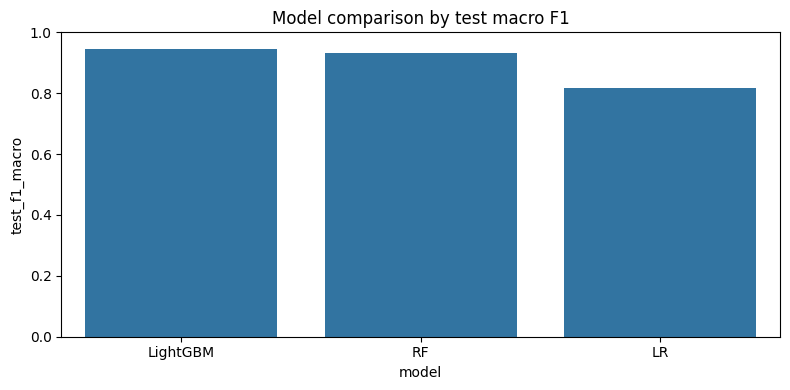

In [14]:
# ========================================
#  Compare and report best model
# ========================================
results = []

results.append({
    "model": "LR",
    "cv_f1_macro": lr_search.best_score_,
    "test_acc": accuracy_score(y_test, pred_lr),
    "test_f1_macro": f1_score(y_test, pred_lr, average="macro")
})

results.append({
    "model": "RF",
    "cv_f1_macro": rf_search.best_score_,
    "test_acc": accuracy_score(y_test, pred_rf),
    "test_f1_macro": f1_score(y_test, pred_rf, average="macro")
})

if LGBM_AVAILABLE and lgbm_search is not None:
    results.append({
        "model": "LightGBM",
        "cv_f1_macro": lgbm_search.best_score_,
        "test_acc": accuracy_score(y_test, pred_lgbm),
        "test_f1_macro": f1_score(y_test, pred_lgbm, average="macro")
    })

results_df = pd.DataFrame(results).sort_values("test_f1_macro", ascending=False)
print(results_df)

best_row = results_df.iloc[0]
print("\nBest model:", best_row["model"])

# Plot
plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x="model", y="test_f1_macro")
plt.title("Model comparison by test macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [15]:
# ========================================
#  Save the best metrics
# ========================================

best_model = lgbm_search.best_estimator_
best_pred = best_model.predict(X_test)

metrics = {
    "model": "LightGBM",
    "test_accuracy": accuracy_score(y_test, best_pred),
    "test_macro_f1": f1_score(y_test, best_pred, average="macro"),
    "test_weighted_f1": f1_score(y_test, best_pred, average="weighted"),
    "cv_macro_f1": lgbm_search.best_score_
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("best_model_metrics.csv", index=False)
print(metrics_df)

      model  test_accuracy  test_macro_f1  test_weighted_f1  cv_macro_f1
0  LightGBM        0.94695       0.946384          0.947009     0.945534


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


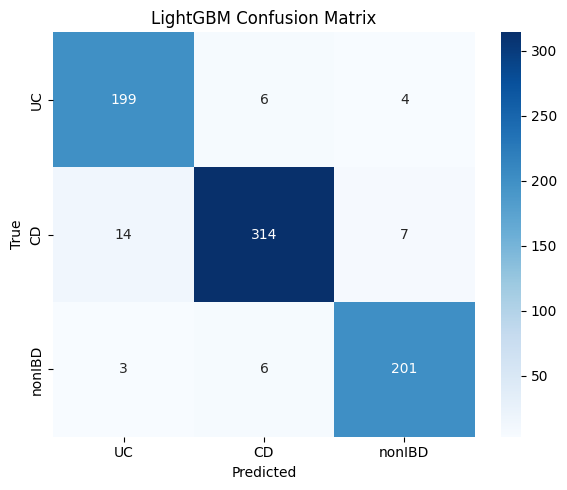

In [16]:
# ========================================
#  Confusion matrix
# ========================================

class_names = ["UC", "CD", "nonIBD"]
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LightGBM Confusion Matrix")
plt.tight_layout()
plt.savefig("lightgbm_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


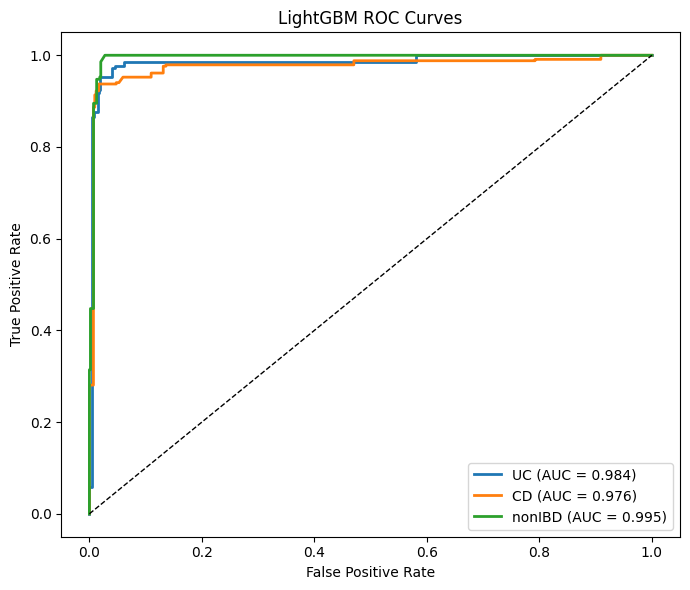

In [18]:
# ========================================
#  ROC curve
# ========================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(7, 6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LightGBM ROC Curves")
plt.legend()
plt.tight_layout()
plt.savefig("lightgbm_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

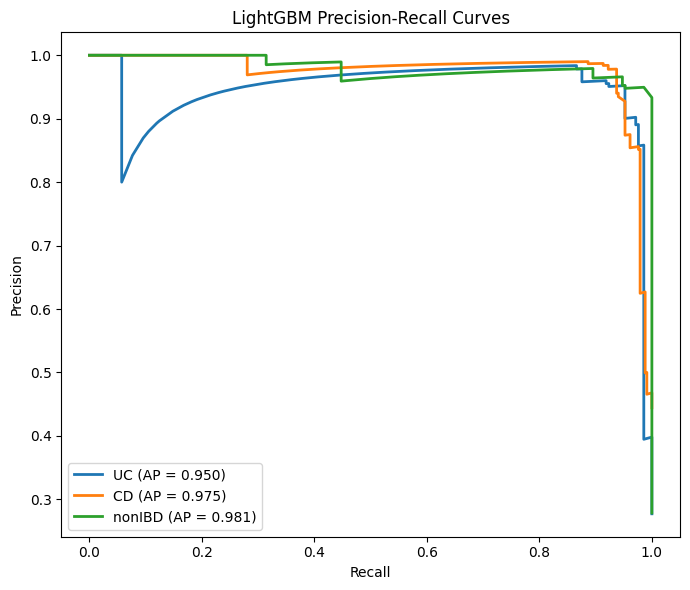

In [19]:
# ========================================
#  Precision-recall curve
# ========================================
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7, 6))
for i, cls in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, lw=2, label=f"{cls} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("LightGBM Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.savefig("lightgbm_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1589/224353692.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


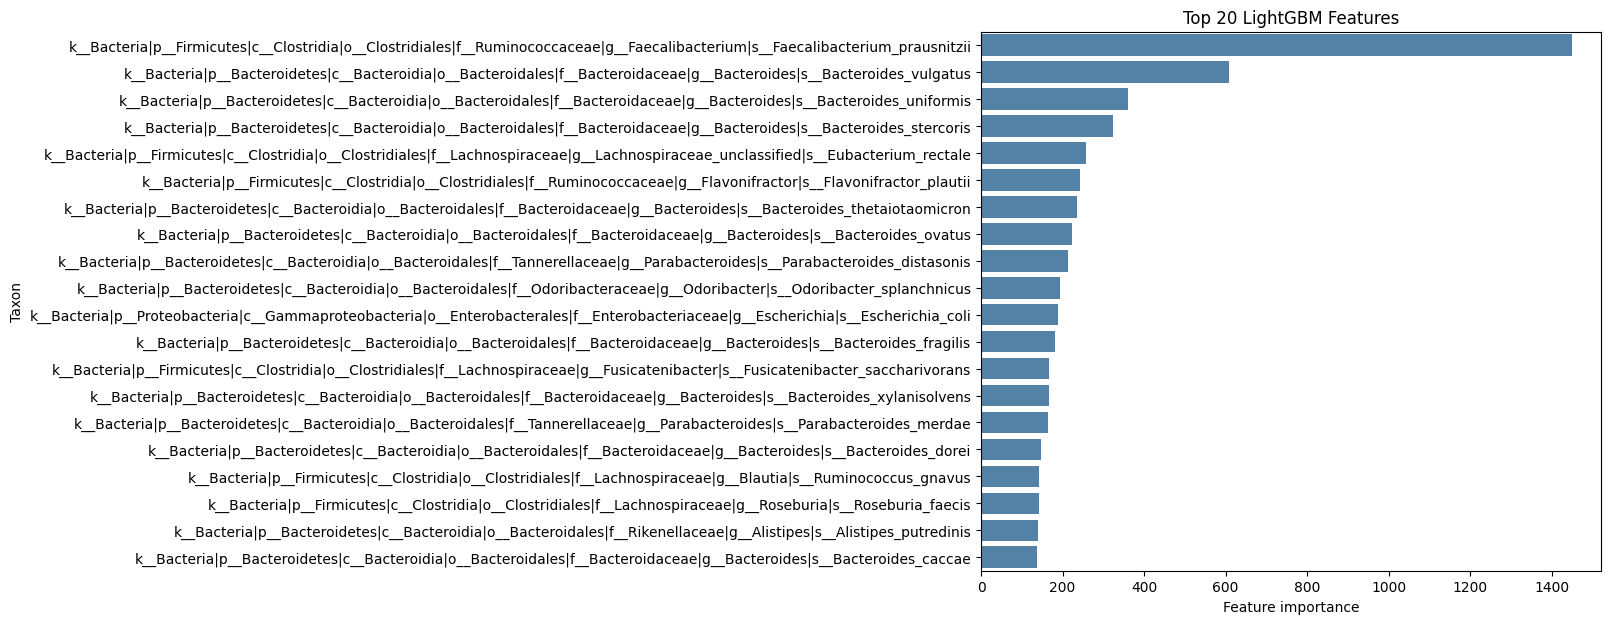

k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Faecalibacterium|s__Faecalibacterium_prausnitzii       1449
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_vulgatus                  609
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_uniformis                 360
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_stercoris                 323
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Lachnospiraceae|g__Lachnospiraceae_unclassified|s__Eubacterium_rectale     258
k__Bacteria|p__Firmicutes|c__Clostridia|o__Clostridiales|f__Ruminococcaceae|g__Flavonifractor|s__Flavonifractor_plautii                244
k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o__Bacteroidales|f__Bacteroidaceae|g__Bacteroides|s__Bacteroides_thetaiotaomicron          235
k__Bacteria|p__Bacteroidete

In [22]:
# ========================================
#  Feature importance
# ========================================
import numpy as np
import pandas as pd

importances = pd.Series(best_model.named_steps["clf"].feature_importances_, index=species_cols)
importances = importances.sort_values(ascending=False)

top20 = importances.head(20)
top20.to_csv("lightgbm_top20_features.csv")

plt.figure(figsize=(8, 7))
sns.barplot(x=top20.values, y=top20.index, color="steelblue")
plt.xlabel("Feature importance")
plt.ylabel("Taxon")
plt.title("Top 20 LightGBM Features")
plt.tight_layout()
plt.savefig("lightgbm_top20_features.png", dpi=300, bbox_inches="tight")
plt.show()

print(top20.to_string())

In [23]:
# ========================================
#  Summary table of all models
# ========================================
summary = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest", "LightGBM"],
    "cv_macro_f1": [lr_search.best_score_, rf_search.best_score_, lgbm_search.best_score_],
    "test_accuracy": [
        accuracy_score(y_test, lr_search.best_estimator_.predict(X_test)),
        accuracy_score(y_test, rf_search.best_estimator_.predict(X_test)),
        accuracy_score(y_test, best_pred),
    ],
    "test_macro_f1": [
        f1_score(y_test, lr_search.best_estimator_.predict(X_test), average="macro"),
        f1_score(y_test, rf_search.best_estimator_.predict(X_test), average="macro"),
        f1_score(y_test, best_pred, average="macro"),
    ],
})

summary = summary.sort_values("test_macro_f1", ascending=False)
summary.to_csv("model_comparison_summary.csv", index=False)
print(summary)

                 model  cv_macro_f1  test_accuracy  test_macro_f1
2             LightGBM     0.945534       0.946950       0.946384
1        Random Forest     0.910774       0.932361       0.932098
0  Logistic Regression     0.814938       0.816976       0.818041
